# 筛选没有问题的家庭

In [1]:
# 数据读取
import pandas as pd

pd.set_option('display.max_columns', None)
family2014 = pd.read_csv('数据/居民出行数据/2014/family_2014.csv',dtype=str)
travel2014 = pd.read_csv('数据/居民出行数据/2014/midtable_2014.csv',dtype=str)
familymember_2014 = pd.read_csv('数据/居民出行数据/2014/family_member_2014.csv',dtype=str)
family2023 = pd.read_csv('数据/居民出行数据/2023/family_total_33169.csv',dtype=str)
travel2023 = pd.read_csv('数据/居民出行数据/2023/midtable_total_33169.csv',dtype=str)
familymember_2023 = pd.read_csv('数据/居民出行数据/2023/familymember_total_33169.csv',dtype=str)
family_cluster = pd.read_csv('数据/family_cluster_improved.csv',dtype=str)
cluster_profile = pd.read_csv('数据/cluster_profile_improved.csv',dtype=str)
cluster_profile.columns
cluster_profile.iloc[:,1:] = cluster_profile.iloc[:,1:].astype(float)
## 家庭变量筛选
valid_member_number = familymember_2023.groupby('家庭编号').size().rename('家庭成员数量_real').reset_index()
family2023 = pd.merge(family2023, valid_member_number, on='家庭编号', how='left')
family2023 = family2023[family2023['家庭成员数量'].astype(int) == family2023['家庭成员数量_real']]
valid_family = family2023[['家庭编号']]
familymember_2023 = pd.merge(familymember_2023, valid_family, on='家庭编号', how='inner')
family2023[['家庭成员数量']].value_counts()
## 家庭连续型变量
family2023[['家庭成员数量','家庭工作人口数','机动车数量','脚踏自行车数量','电动自行车数量','摩托车数量','老年代步车数量']]
have_student_family = familymember_2023[familymember_2023['职业'] == '14'].drop_duplicates(['家庭编号'])[['家庭编号']]
have_student_family['have_student'] = 1
family2023 = pd.merge(family2023, have_student_family, on='家庭编号', how='left').fillna({'have_student':0})
## 家庭离散型变量
family2023[['have_student','家庭年收入']]
family2023['家庭年收入'].isna().sum()
## 个人变量筛选
familymember_2023['age'] = 2023 - familymember_2023['出生年份'].astype(int)
familymember_2023['age_group'] = pd.cut(familymember_2023['age'], bins=[0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100], right=False, labels=['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','41-45','46-50','51-55','56-60','61-65','66-70','71-75','76-80','81-85','86-90','91-95','96-100'])
familymember_2023['age'].max() , familymember_2023['age'].min()
# familymember_2023['age'] = (familymember_2023['age'] - familymember_2023['age'].min()) / (familymember_2023['age'].max() - familymember_2023['age'].min())
## 连续型变量
familymember_2023[['age']]
(familymember_2023[familymember_2023['关系']=='0']['age']).describe()
familymember_2023.loc[familymember_2023['最高学历'].isna(),'最高学历'] = familymember_2023.loc[familymember_2023['最高学历'].isna(),'教育阶段']
## 离散型变量,这里的关系有点不太对，有的户主很小
familymember_2023[['性别','是否有驾照','关系','最高学历','职业']]
familymember_2023['是否有驾照'] = familymember_2023['是否有驾照'].fillna('0')

In [2]:
import numpy as np
## 变量编码
income_map = {'A':1, 'B':1, 'C':2, 'D':2, 'E':3, 'F':3, 'G':4, 'I':5, 'J':5, 'K':5}
family2023['家庭年收入'] = family2023['家庭年收入'].map(income_map)
familymember_2023['age_group'] = pd.cut(
    familymember_2023['age'], 
    bins=range(0, familymember_2023['age'].max() + 6, 5),
    labels=False 
)


familymember_2023['age_group'] = familymember_2023['age_group'].fillna(0)
familymember_2023['age'] = familymember_2023['age_group']
# relation_map = {'0':0, '17':1, '1':2, '2':2, '5':2, '6':2, '13':3, '14':3, '15':3, '16':3, '9':3, '10':3, '7':4, '8':4, '11':5, '12':5}
# education_map = {'1':1, '2':1, '3':2, '4':2, '5':3, '6':4, '7':5, '8':6, '9':7}
# occupation_map = {'1':1, '2':1, '3':1, '4':2, '5':2, '6':3, '7':2, '8':3, '9':1, '10':4, '11':4, '12':4, '13':5, '14':6, '15':7, '16':8, '17':8, '18':1, '19':1, '20':8}

# familymember_2023['关系'] = familymember_2023['关系'].map(relation_map)
# familymember_2023['最高学历'] = familymember_2023['最高学历'].map(education_map)
# familymember_2023['职业'] = familymember_2023['职业'].map(occupation_map)
familymember_2023['关系'].value_counts().shape, familymember_2023['最高学历'].value_counts().shape, familymember_2023['职业'].value_counts().shape



((16,), (9,), (20,))

In [3]:
family2023

,编号,家庭编号,所属城区,所属街道,所属社区,添加地址,家庭具体地址,小区编号,小区编号的环路代码,家庭流动人口数,家庭工作人口数,家庭学生人口数,家庭无业人口数,地址经度,地址纬度,调查员编号,调查员姓名,第1次入户时间,第1次敲门状态,第2次入户时间,第2次敲门状态,出行日期,家庭成员数量,住房类型,住房类型其他,住房类型_final,建筑面积,在北京是否更换过居住地址,本户居住起始年份,上一居住地址,上一居住地址经度,上一居住地址纬度,上一居住小区编码,家庭年收入,取快递次数,取外卖次数,脚踏自行车数量,电动自行车数量,摩托车数量,老年代步车数量,机动车数量,状态,成员信息登记状态,成员信息创建时间,成员信息更新时间,车辆信息登记状态,车辆信息创建时间,车辆信息更新时间,住房信息登记状态,住房信息创建时间,住房信息更新时间,出行信息登记状态,行程信息创建时间,出行信息更新时间,调查时的所在位置经度,调查时的所在位置纬度,调查时的所在位置定位时间,创建时间,修改时间,年度,项目名称,type,no.na,家庭成员数量_real,have_student
0,000b2a2b-1333-4d28-8056-8ab1a30870ad,010703000170,2,月坛街道,月坛社区,月坛西街东里21号院16,月坛西街东里21号院1号楼905,010703,3,0,2,0,0,116.349759,39.916528,e4decdee-2b98-4231-b1be-80537da8f151,郭建立,2023/5/15 0:00:00,success,2023/5/18 0:00:00,success,2023/5/16 0:00:00,3,1,-1,1,43.5,0,-1,-1,0,0,-1,3,0,0,3,0,0,0,1,success,saved,2023/5/27 13:25:45,2023/5/27 13:25:44,saved,2023/5/10 10:30:07,2023/6/5 8:49:48,saved,-1,2023/5/27 13:28:51,saved,-1,2023/6/5 8:50:03,NaN,NaN,NaN,2023/5/10 10:30:07,2023/6/8 10:48:55,2023,第六次北京城市交通综合调查（交研都市）,jy,3,3,0.0
1,003d14b7-e5fb-4b53-b10d-ebb4342af81b,040603000173,2,广安门外街道,鸭子桥社区,运达小区004,运达小区18-6-201,040501,3,0,2,0,0,116.345741,39.877241,2b4ad7c1-b331-484b-b6f3-3ba60e5c012e,孙丽群,2023/5/20 0:00:00,success,2023/5/22 0:00:00,success,2023/5/21 0:00:00,2,1,-1,1,70,0,-1,-1,0,0,-1,2,2,0,1,0,0,0,1,success,saved,2023/5/22 12:35:02,2023/5/22 12:36:29,saved,2023/5/20 8:56:11,2023/5/22 12:37:32,saved,-1,2023/5/22 12:37:51,saved,-1,2023/5/22 12:42:31,116.345699,39.877231,2023/5/22 15:12:50,2023/5/20 8:56:11,2023/6/4 22:13:44,2023,第六次北京城市交通综合调查（交研都市）,jy,0,2,0.0
2,00469d0e-2b5f-476f-bf86-ee554e9e3752,010305000086,2,展览路街道,新华里社区,新华里16号院10号楼020,新华里16号院10-2-702,010512,3,0,2,0,0,116.352423,39.935196,0d9d0be5-91d5-42b4-97ed-696f02298e48,王莹,2023/5/23 0:00:00,success,2023/5/25 0:00:00,success,2023/5/24 0:00:00,2,1,-1,1,127,0,-1,-1,0,0,-1,2,2,0,0,1,0,0,1,passed,saved,2023/5/25 9:53:24,2023/5/25 9:53:23,saved,2023/5/22 15:25:46,2023/5/25 9:55:30,saved,-1,2023/5/25 9:55:49,saved,-1,2023/5/25 10:02:23,116.352662,39.935372,2023/5/25 9:18:36,2023/5/22 15:25:46,2023/6/13 11:27:27,2023,第六次北京城市交通综合调查（交研都市）,jy,0,2,0.0
3,004aadb2-8693-438e-b358-56e75ade505e,040505000015,2,广安门外街道,红莲南里社区居委会,常青藤嘉园15,西城区常青藤嘉园2号院3-1106,040506,3,0,2,1,0,116.333144,39.880115,851e42f9-61cd-4ca8-9f28-5ae0544d4b97,李满慧,2023/4/19 0:00:00,success,2023/4/21 0:00:00,success,2023/4/20 0:00:00,3,1,-1,1,70,0,-1,-1,0,0,-1,4,1,0,1,1,0,0,1,success,saved,2023/4/23 18:23:57,2023/4/23 18:23:57,saved,2023/4/17 15:15:24,2023/4/24 22:30:47,saved,-1,2023/4/23 18:24:57,saved,-1,2023/4/25 15:50:29,NaN,NaN,NaN,2023/4/17 15:15:24,2023/5/9 10:37:51,2023,第六次北京城市交通综合调查（交研都市）,jy,3,3,1.0
4,004c99c2-2690-461d-8463-d1850d911656,120201000011,11,庞各庄镇,东中堡村村委会,东中堡村19,东中堡村东街北三条4号,120203,7,0,2,0,0,116.324315,39.644375,d9554d3c-a98a-4f36-afa7-f9565c2d1d76,崔玉晶,2023/6/6 0:00:00,success,2023/6/8 0:00:00,success,2023/6/7 0:00:00,2,6,-1,6,200,0,-1,-1,0,0,-1,1,0,0,1,2,0,0,1,success,saved,2023/6/6 11:30:46,2023/6/6 11:30:46,saved,2023/6/4 23:14:28,2023/6/6 11:32:13,saved,-1,2023/6/6 11:32:35,saved,-1,2023/6/29 11:25:59,116.324315,39.644375,2023/6/6 11:28:16,2023/6/4 23:14:28,2023/6/29 11:26:10,2023,第六次北京城市交通综合调查（交研都市）,jy,0,2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33161,fff6ec7b-8fa8-453c-b557-2f4c3f6eb05b,132021000002,7,长阳镇,加州水郡东区社区,01,64号楼1单元802,132021,6,0,0,0,0,116.167937,39.767044,6464bd57-78b5-c674-0013-007c01cd8e3e,左金风,2023/5/19 0:00:00,success,2023/5/23 0:00:00,success,2023/5/22 0:00:00,1,1,-1,1,110,0,-1,-1,0,0,-1,1,0,0,1,0,0,0,0,success,saved,2023/5/20 20:13:46,2023/5/23 15:18:21,saved,2023/5/19 10:21:45,2023/5/23 15:18:34,saved,-1,2023/5/23 15:18:50,saved,-1,2023/5/23 20:11:10,116.168532,39.767891,2023/5/19 11:30:13,2023/5/19 10:21:45,2023/5/23 20:11:17,2023,第六次北京城市交通综合调查（民生智库）,ms,0,1,0.0
33162,fffa6aad-791f-420d-b0dc-

# 活动链提取

In [4]:
travelinfo = pd.read_csv('数据/居民出行数据/2023/midtable_total_33169.csv',dtype=str)

In [5]:
travelinfo = pd.merge(travelinfo, family2023[['家庭编号']])

In [6]:
## 活动链太大的去除掉
travel_num_the = travelinfo.groupby(['家庭编号','家庭成员编号']).size().rename('出行次数').reset_index()
more_travel = travel_num_the[travel_num_the['出行次数']>6][['家庭编号']].drop_duplicates()

In [7]:
family2023 = family2023[-family2023['家庭编号'].isin(more_travel['家庭编号'])]

In [8]:
travelinfo = pd.merge(travelinfo, family2023[['家庭编号']])
familymember_2023 = pd.merge(familymember_2023, family2023[['家庭编号']])

In [9]:
## 没有出行的家庭

In [10]:
have_travel_family = travelinfo[['家庭编号']].value_counts().reset_index()[['家庭编号']]

In [11]:
family2023 = family2023[family2023['家庭编号'].isin(have_travel_family['家庭编号'])]
travelinfo = pd.merge(travelinfo, family2023[['家庭编号']])
familymember_2023 = pd.merge(familymember_2023, family2023[['家庭编号']])

In [12]:
## 开头不是家出行的去除掉
no_home_travel = travelinfo[travelinfo['全日出行链'].str[0] != 'H'][['家庭编号']].drop_duplicates()
family2023 = family2023[-family2023['家庭编号'].isin(no_home_travel['家庭编号'])]
travelinfo = pd.merge(travelinfo, family2023[['家庭编号']])
familymember_2023 = pd.merge(familymember_2023, family2023[['家庭编号']])

## 目的、方式、时间、车辆、陪同

In [13]:
## 加入出行OD信息

In [14]:
activityinfo = travelinfo[['家庭编号','家庭成员编号','出行序号','出行目的','交通方式的编号','ModelMode','出发时间1小时时间段','到达时间1小时时间段','是驾驶员还是乘客','是否和家庭成员的联合出行','起点经度','起点纬度','结束经度','结束纬度']]

In [15]:
## 1:步行;2:自行车、电动自行车；3:公交、地铁；4:小汽车、出租车；5:其他
## 1:步行、自行车、电动自行车；2:公交、地铁；3:小汽车、出租车；4:其他
## 1:步行；2:公交；3:地铁；4:自行车；5:电动自行车；6:小汽车；7:其他机动车；8:班车类； 9:出租 ;10:摩托车; 11:其他

class_map2023 = {
    "1": "1",
    "2.1": "6",
    "2.2": "7",
    "2.3": "7",
    "3": "7",
    "4": "7",
    "5": "10",
    "6": "3",
    "7": "2",
    "8": "9",
    "9": "9",
    "10": "8",
    "11": "8",
    "12": "8",
    "13": "4",
    "14": "4",
    "15": "4",
    "16": "5",
    "17": "11",
    "18": "11",
    "19": "11"
}


In [16]:
activityinfo['是驾驶员还是乘客'] = activityinfo['是驾驶员还是乘客'].fillna('0')

/tmp/ipykernel_20596/200093675.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activityinfo['是驾驶员还是乘客'] = activityinfo['是驾驶员还是乘客'].fillna('0')


In [17]:
activityinfo['ModelMode'] = activityinfo['交通方式的编号'].map(class_map2023)

/tmp/ipykernel_20596/1644536957.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activityinfo['ModelMode'] = activityinfo['交通方式的编号'].map(class_map2023)


In [18]:
#2023数据
# 1：工作
# 2：外出就餐
# 3：公务外出
# 4：上学/校外托管
# 5：探亲访友
# 7：休闲娱乐健身
# 8：个人事务
# 10：接送人
# 13：购物
# 14：其他
# 15：回另一居住地
# 21：下班回家
# 22：放学回家
# 23：个人事务回家
# 24：其他回家

# 1：在家（15,21,22,23,24）
# 2: 工作（1）
# 3：上学（4）
# 4：公务外出类（3）
# 5：外出吃饭
# 6：探亲访友
# 7：休闲娱乐
# 8：购物
# 9：接送人
# 10：其他（8，14）
def get_activity_type2023(r):
    if r in ['15','21','22','23','24']:
        return '1'
    elif r == '1':
        return '2'
    elif r == '4':
        return '3'
    elif r == '3':
        return '4'
    elif r == '2':
        return '5'
    elif r == '5':
        return '6'
    elif r == '7':
        return '7'
    elif r == '13':
        return '8'
    elif r in ['10']:
        return '9'
    elif r in ['8', '14']:
        return '10'

In [19]:
activityinfo['ActivityType'] = activityinfo['出行目的'].apply(get_activity_type2023)

/tmp/ipykernel_20596/974261224.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activityinfo['ActivityType'] = activityinfo['出行目的'].apply(get_activity_type2023)


In [20]:
import geopandas as gpd
taz_data = gpd.read_file('数据/北京市交通小区/北京市交通小区.shp')


In [21]:
taz_data = taz_data.sort_values('zoneID')

In [22]:
taz_data['new_zoneID'] = range(len(taz_data))

In [23]:
id_map = taz_data[['zoneID','new_zoneID']].set_index('zoneID').to_dict()['new_zoneID']

In [24]:
taz_data = taz_data.to_crs(epsg=4326)

In [25]:
activityinfo['geometry_start'] = gpd.points_from_xy(activityinfo['起点经度'].astype(float), activityinfo['起点纬度'].astype(float))
activityinfo['geometry_end'] = gpd.points_from_xy(activityinfo['结束经度'].astype(float), activityinfo['结束纬度'].astype(float))
activityinfo = gpd.GeoDataFrame(activityinfo, geometry='geometry_start', crs='EPSG:4326')
activityinfo = gpd.sjoin(activityinfo, taz_data[['new_zoneID','geometry']], how='left', predicate='within')
activityinfo = activityinfo.rename(columns={'new_zoneID':'origin_tazID'})
activityinfo = gpd.GeoDataFrame(activityinfo, geometry='geometry_end', crs='EPSG:4326')
activityinfo.drop(columns=['index_right'], inplace=True)
activityinfo = gpd.sjoin(activityinfo, taz_data[['new_zoneID','geometry']], how='left', predicate='within')
activityinfo = activityinfo.rename(columns={'new_zoneID':'destination_tazID'})

/tmp/ipykernel_20596/1906161379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activityinfo['geometry_start'] = gpd.points_from_xy(activityinfo['起点经度'].astype(float), activityinfo['起点纬度'].astype(float))
/tmp/ipykernel_20596/1906161379.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  activityinfo['geometry_end'] = gpd.points_from_xy(activityinfo['结束经度'].astype(float), activityinfo['结束纬度'].astype(float))


In [26]:
## 出发地点或到达地点无法匹配上的家庭去除掉

start_nan = activityinfo[activityinfo['origin_tazID'].isna()][['家庭编号']].drop_duplicates()
family2023 = family2023[-family2023['家庭编号'].isin(start_nan['家庭编号'])]
activityinfo = pd.merge(activityinfo, family2023[['家庭编号']])
familymember_2023 = pd.merge(familymember_2023, family2023[['家庭编号']])

end_nan = activityinfo[activityinfo['destination_tazID'].isna()][['家庭编号']].drop_duplicates()
family2023 = family2023[-family2023['家庭编号'].isin(end_nan['家庭编号'])]
activityinfo = pd.merge(activityinfo, family2023[['家庭编号']])
familymember_2023 = pd.merge(familymember_2023, family2023[['家庭编号']])

In [27]:
## 家庭地址匹配不上的去除
family2023['geometry'] = gpd.points_from_xy(family2023['地址经度'].astype(float), family2023['地址纬度'].astype(float))
family2023 = gpd.GeoDataFrame(family2023, geometry='geometry', crs='EPSG:4326')
family2023 = gpd.sjoin(family2023, taz_data[['new_zoneID','geometry']], how='left', predicate='within')

In [28]:
## 工作地址匹配不上的去除
familymember_2023['geometry'] = gpd.points_from_xy(familymember_2023['单位/学校地址的经度'].astype(float), familymember_2023['单位/学校地址的纬度'].astype(float))
familymember_2023 = gpd.GeoDataFrame(familymember_2023, geometry='geometry', crs='EPSG:4326')
familymember_2023 = gpd.sjoin(familymember_2023, taz_data[['new_zoneID','geometry']], how='left', predicate='within')

In [29]:
wrong_work_place = familymember_2023[((familymember_2023['new_zoneID'].isna()) & (familymember_2023['单位/学校地址的经度'] != '0'))][['家庭编号']].drop_duplicates()
family2023 = family2023[-family2023['家庭编号'].isin(wrong_work_place['家庭编号'])]
activityinfo = pd.merge(activityinfo, family2023[['家庭编号']])
familymember_2023 = pd.merge(familymember_2023, family2023[['家庭编号']])

# 训练集和测试集保存

In [30]:
## 没有出行的人的活动链

In [31]:
from population_data_process_nonclip_reclass import *
## 家庭的变量编码
test = PopulationDataEncoder()
family_cluster.rename(columns={'improved_cluster':'cluster'}, inplace=True)
family2023 = pd.merge(family2023,family_cluster[['家庭编号','cluster']], on='家庭编号', how='left')
cluster_profile.rename(columns={'improved_cluster':'cluster'}, inplace=True)
# 2. 拟合数据 (需要你的实际数据)
test.fit_family_data(family2023)
test.fit_person_data(familymember_2023)
test.fit_activity_data(activityinfo, id_map)

/home/cranehh/anaconda3/envs/DiT/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [134]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# 处理缺失值
data_to_fit = activityinfo[['ModelMode']].astype(int).fillna('-1')
ohe.fit(data_to_fit)

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [135]:
ohe.transform([[10]])

/home/cranehh/anaconda3/envs/DiT/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])

In [132]:
test.onehot_encoders['activity_ModelMode'].transform([['10']])

/home/cranehh/anaconda3/envs/DiT/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [126]:
activityinfo['ModelMode']

0         1
1         1
2         8
3         8
4         6
         ..
163605    1
163606    6
163607    6
163608    2
163609    2
Name: ModelMode, Length: 163610, dtype: object

In [32]:
# family_encoded = test.encode_family(family2023, cluster_profile)
# person_encoded = test.encode_person(familymember_2023)
# activity_encoded = test.encode_activity(activityinfo)

In [33]:
# # 构建训练样本
# family_samples = []
# member_samples = []
# family_ids = family2023['家庭编号'].unique()
# family_id = family_ids[0]
# max_family_size = 8

# # 家庭信息
# family_idx = family2023[family2023['家庭编号'] == family_id].index[0]
# family_features = []

# # 家庭连续变量
# for col in test.family_continuous_cols:
#     family_features.append(family_encoded[f'family_{col}'][family_idx])

# # 家庭离散变量 (one-hot编码后是向量)
# for col in test.family_categorical_cols:
#     onehot_vector = family_encoded[f'family_{col}'][family_idx]
#     family_features.extend(onehot_vector.tolist())
# family_features.extend([family_encoded['family_cluster'][family_idx]])  # 添加聚类标签
# family_features.extend([val for val in family_encoded['cluster_profile'][family_idx]])  # 添加聚类特征
# # 成员信息
# family_members = familymember_2023[familymember_2023['家庭编号'] == family_id]
# family_members = family_members.sort_values('age', ascending=False)
# member_features = []
# activity_family = []

# for _, member in family_members.iterrows():
#     member_feature = []
#     # 个人连续变量
#     member_feature.append(person_encoded['person_age'][member.name])
#     # 个人离散变量 (one-hot编码后是向量)
#     for col in test.person_categorical_cols:
#         onehot_vector = person_encoded[f'person_{col}'][member.name]
#         member_feature.extend(onehot_vector.tolist())
#     member_feature.append(1) # 标记为有效成员
#     member_features.extend(member_feature)

#     member_info = family_members[family_members.index == member.name][['家庭编号','成员编号']].values[0]
#     member_activity = activityinfo[(activityinfo['家庭编号'] == member_info[0]) & (activityinfo['家庭成员编号'] == member_info[1])].sort_values('出行序号')
#     activity_features = []
#     if len(member_activity) == 0:
#         # 如果没有活动链，填充全0
#         max_activity_chain_length = 6
#         activity_feature_dim = len(test.activity_continuous_cols) + sum(test.activity_categorical_dims)
#         activity_features.extend([0] * (max_activity_chain_length * activity_feature_dim))
#     for _, activity in member_activity.iterrows():
#         activity_feature = []
#         # 活动连续变量
#         for col in test.activity_continuous_cols:
#             activity_feature.append(activity_encoded[f'activity_{col}'][activity.name])
#         # 活动离散变量 (one-hot编码后是向量)
#         for col in test.activity_categorical_cols:
#             onehot_vector = activity_encoded[f'activity_{col}'][activity.name]
#             activity_feature.extend(onehot_vector.tolist())
#         activity_features.extend(activity_feature)
#     # 填充到最大活动链长度
#     max_activity_chain_length = 6
#     current_activities = len(member_activity)
#     activity_feature_dim = len(test.activity_continuous_cols) + sum(test.activity_categorical_dims)
#     if current_activities < max_activity_chain_length:
#         padding_size = (max_activity_chain_length - current_activities) * activity_feature_dim
#         activity_features.extend([0] * padding_size)   

# # 填充到最大家庭大小
# current_members = len(family_members)
# # 计算每个成员的特征维度：1个连续变量 + 所有离散变量的one-hot维度之和
# person_feature_dim = 1 + sum(test.person_categorical_dims)

# if current_members < max_family_size:
#     # 用0填充缺失成员
#     padding_size = (max_family_size - current_members) * (person_feature_dim + 1) # 标记无效成员
#     member_features.extend([0] * padding_size)
# elif current_members > max_family_size:
#     # 截断超出的成员
#     member_features = member_features[:max_family_size * person_feature_dim]

# # 组合完整样本
# family_samples.append(family_features)
# member_samples.append(member_features)
# activity_family.append(activity_features)

# # 计算正确的reshape维度
# person_feature_dim = 1 + sum(test.person_categorical_dims) + 1  # +1 for valid member flag

In [34]:
# member_info = family_members[family_members.index == member.name][['家庭编号','成员编号']].values[0]
# member_activity = activityinfo[(activityinfo['家庭编号'] == member_info[0]) & (activityinfo['家庭成员编号'] == member_info[1])].sort_values('出行序号')
# activity_features = []
# if len(member_activity) == 0:
#     # 如果没有活动链，填充全0
#     max_activity_chain_length = 6
#     activity_feature_dim = len(test.activity_continuous_cols) + sum(test.activity_categorical_dims)
#     activity_features.extend([0] * (max_activity_chain_length * activity_feature_dim))
# for _, activity in member_activity.iterrows():
#     activity_feature = []
#     # 活动连续变量
#     for col in test.activity_continuous_cols:
#         activity_feature.append(activity_encoded[f'activity_{col}'][activity.name])
#     # 活动离散变量 (one-hot编码后是向量)
#     for col in test.activity_categorical_cols:
#         onehot_vector = activity_encoded[f'activity_{col}'][activity.name]
#         activity_feature.extend(onehot_vector.tolist())
#     activity_features.extend(activity_feature)
# # 填充到最大活动链长度
# max_activity_chain_length = 6
# current_activities = len(member_activity)
# activity_feature_dim = len(test.activity_continuous_cols) + sum(test.activity_categorical_dims)
# if current_activities < max_activity_chain_length:
#     padding_size = (max_activity_chain_length - current_activities) * activity_feature_dim
#     activity_features.extend([0] * padding_size)    




In [35]:
sampled_df = family2023.groupby('所属城区', group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42)
)
family2023_train = pd.concat([sampled_df, family2023], axis=0).drop_duplicates(keep=False)
familymember_2023_train = pd.merge(familymember_2023, family2023_train[['家庭编号']], on='家庭编号', how='inner')

familymember_2023_test = pd.merge(familymember_2023, sampled_df[['家庭编号']], on='家庭编号', how='inner')
family2023_train = family2023_train.reset_index()
sampled_df = sampled_df.reset_index()

In [36]:
activityinfo_train = pd.merge(activityinfo, family2023_train[['家庭编号']], on='家庭编号', how='inner')
activityinfo_test = pd.merge(activityinfo, sampled_df[['家庭编号']], on='家庭编号', how='inner')

In [37]:
family_gmm = np.load("gmm/family_patterns_demo.npy")
individual_gmm = np.load("gmm/individual_patterns_demo.npy")
import json
with open("gmm/household_mapping_demo.json", "r") as f:
    household_mapping = json.load(f)

In [38]:
pattern_train_ls = []
for i in range(len(family2023_train)):
    family_id = family2023_train.loc[i, '家庭编号']
    pattern_train_ls.append(household_mapping[family_id])

In [39]:
pattern_test_ls = []
for i in range(len(sampled_df)):
    family_id = sampled_df.loc[i, '家庭编号']
    pattern_test_ls.append(household_mapping[family_id])

In [40]:
test_index = [0, 1, 2, 3, 4, 5, 6, 7]

In [47]:
dataset_family, dataset_member, dataset_activity = create_population_dataset(family2023_train, familymember_2023_train, activityinfo_train, test, cluster_profile)

In [50]:
dataset_family.shape, dataset_member.shape, dataset_activity.shape

(torch.Size([3219, 81]),
 torch.Size([3219, 8, 52]),
 torch.Size([3219, 8, 6, 29]))

In [48]:
# 3. 创建数据集
# dataset_family, dataset_member, dataset_activity = create_population_dataset(family2023_train, familymember_2023_train, activityinfo_train, test, cluster_profile)
np.save('数据/family_sample_improved_cluster_train.npy',dataset_family.numpy())
np.save('数据/family_member_sample_improved_cluster_train.npy',dataset_member.numpy())
np.save('数据/family_activity_train.npy',dataset_activity.numpy())

dataset_family, dataset_member, dataset_activity = create_population_dataset(sampled_df, familymember_2023_test, activityinfo_test, test, cluster_profile)
np.save('数据/family_sample_improved_cluster_test.npy',dataset_family.numpy())
np.save('数据/family_member_sample_improved_cluster_test.npy',dataset_member.numpy())
np.save('数据/family_activity_test.npy',dataset_activity.numpy())

In [49]:
np.save('数据/family_pattern_train.npy',family_gmm[pattern_train_ls])
np.save('数据/family_pattern_test.npy',family_gmm[pattern_test_ls])
np.save('数据/person_pattern_train.npy',individual_gmm[pattern_train_ls])
np.save('数据/person_pattern_test.npy',individual_gmm[pattern_test_ls])

# 模型效果测试

In [32]:
## 加了SS的 —— 12.07
## 增加模型的rollout —— 12.08
## 减少了层数 防止过拟合 分别减少到 10 和 5 层， 增加了SS的激进程度， 验证的结果和rollout 也差不多，但是过拟合现象有所缓解 —— 12.08
## 进一步增加了drop out比例和 rollout的强度，效果有所提升 —— 12.09
## 增加了gmm的预测和条件信息
## 更改了ar和损失函数
## 增加了ar的内部逻辑和输出头的条件融合
## 增加了每一层transformer_decoder的调制
## 第一次增加关于目的地的预测
## 采用了更好的PLE结构
## 采用了更保守的SS策略，对应215bf5f (HEAD -> main, origin/main) new_validation，对应checkpoints_ss_with_condition_lessSS文件夹
## 更改了学习率、衰减率、减小了一层CGC、激进了一下SS策略，对应bd14f3b (HEAD -> main, origin/main, origin/HEAD) validition，对应checkpoints_ss_with_condition_learning文件夹
## 采用了更少的家庭活动和个人活动模式数量，对应84e2114 (HEAD -> main, origin/main, origin/HEAD) less_cluster，对应checkpoints_ss_with_condition_lesscluster文件夹
## 采用了focalloss代替原来的gmm_loss，对应5c8d32f (HEAD -> main, origin/main, origin/HEAD) new_gmm_loss，对应checkpoints_ss_with_condition_newgmmloss文件夹
## 加入了方式预测对于目的地的感知，对应c1a2670 (HEAD -> main, origin/main, origin/HEAD) revise_batch，对应checkpoints_ss_with_condition_distance文件夹
## 加入了方式预测对于目的地距离的分箱感知等，对应e22cbbe (HEAD -> main, origin/main, origin/HEAD) better_distance，对应checkpoints_ss_with_condition_betterdistance文件夹
## 添加了蒸馏模型，对应b483586 (HEAD -> fix-from-gmm, origin/fix-from-gmm) fix，对应checkpoints_ss_with_condition_distill文件夹
## 新的nash模型，但是有end，对应fd87368 (HEAD, origin/new_nash, new_nash) completed_nash，对应checkpoints_ss_with_condition_nash文件夹
## 去掉end的nash模型，对应e985661 (HEAD -> new_nash, origin/new_nash) no_end_nash，对应checkpoints_ss_with_condition_nash_without_end文件夹
## 改善了一些模型的梯度问题，对应6af937d (HEAD -> new_nash, origin/new_nash) fix_grad，对应checkpoints_ss_with_condition_nash_without_end2文件夹
## 修复了一些小问题，对应43fa934 (HEAD -> new_nash, origin/new_nash) fix_issue，对应checkpoints_ss_with_condition_nash_without_end3文件夹

## 数据复原过程

In [33]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import time
import logging
from typing import Dict, Optional
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import numpy as np
from tqdm import tqdm
import sys
sys.path.append('family_tour_generation')

from family_tour_generation.config import ModelConfig, TrainConfig
from family_tour_generation.data import FamilyTourBatch, FamilyTourDataset, collate_fn
from family_tour_generation.model import FamilyTourGenerator, create_model
from family_tour_generation.losses import FamilyTourLoss, MetricsCalculator
from family_tour_generation.train import *
from family_tour_generation.exposure_bias import (
    ExposureBiasTrainer,
    ScheduledSamplingScheduler,
    create_exposure_bias_handler
)
class ScheduledSamplingTrainer:
    """
    使用 Scheduled Sampling 的训练器
    """

    def __init__(
            self,
            model: nn.Module,
            model_config: ModelConfig,
            train_config: TrainConfig,
            train_loader: DataLoader,
            val_loader: DataLoader = None,
            save_dir: str = './checkpoints',
            eb_strategy: str = 'scheduled_sampling'
    ):
        self.model = model
        self.model_config = model_config
        self.train_config = train_config
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)

        # 设备
        self.device = torch.device(
            train_config.device if torch.cuda.is_available() else 'cpu'
        )
        self.model.to(self.device)

        # Exposure Bias 处理器
        self.eb_trainer = create_exposure_bias_handler(
            model, model_config, strategy=eb_strategy
        )

        # 损失函数
        self.criterion = FamilyTourLoss(model_config, train_config)

        # 优化器
        self.optimizer = optim.AdamW(
            model.parameters(),
            lr=train_config.learning_rate,
            weight_decay=train_config.weight_decay,
            betas=(0.9, 0.98)
        )

        # 学习率调度
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2
        )

        # 混合精度
        self.scaler = GradScaler()
        self.use_amp = torch.cuda.is_available()

        # 状态
        self.current_epoch = 0
        self.global_step = 0
        self.best_val_loss = float('inf')

        # 指标
        self.metrics_calc = MetricsCalculator()

    def train_epoch(self):
        """训练一个 epoch"""
        self.model.train()

        total_loss = 0.0
        loss_components = {k: 0.0 for k in self.model_config.loss_weights.keys()}
        num_batches = 0

        pbar = tqdm(self.train_loader, desc=f'Epoch {self.current_epoch}')

        for batch_data in pbar:

            batch = batch_data.to(self.device)

            self.optimizer.zero_grad()

            if self.use_amp:
                with autocast():
                    loss, losses = self.eb_trainer.train_step(
                        batch, self.criterion, self.optimizer, self.current_epoch
                    )

                # ---- NaN detection: forward pass ----
                if torch.isnan(loss):
                    print(f"\n[NaN DEBUG] loss is NaN at epoch={self.current_epoch}, "
                          f"step={self.global_step}, batch={num_batches}")
                    for k, v in losses.items():
                        if torch.is_tensor(v) and torch.isnan(v):
                            print(f"  loss component '{k}' is NaN")
                    print(f"  AMP scaler scale={self.scaler.get_scale():.4f}")

                try:
                    self.scaler.scale(loss).backward()
                except RuntimeError as e:
                    # Safety net: catch backward LU errors from qpth KKT
                    print(f"\n[NaN DEBUG] backward failed at epoch={self.current_epoch}, "
                          f"step={self.global_step}: {e}")
                    self.optimizer.zero_grad()
                    # Skip scaler.update() — no inf checks recorded, calling update would assert
                    continue

                # ---- NaN detection: gradients ----
                self.scaler.unscale_(self.optimizer)
                total_grad_norm = torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), self.train_config.grad_clip
                )
                if torch.isnan(total_grad_norm) or total_grad_norm > 1e6:
                    print(f"\n[NaN DEBUG] grad_norm={total_grad_norm:.4f} at epoch={self.current_epoch}, "
                          f"step={self.global_step}")

                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                loss, losses = self.eb_trainer.train_step(
                    batch, self.criterion, self.optimizer, self.current_epoch
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), self.train_config.grad_clip
                )
                self.optimizer.step()

            # 统计
            total_loss += loss.item()
            for k, v in losses.items():
                loss_components[k] += v.item()
            num_batches += 1
            self.global_step += 1

            # 获取当前 TF 概率
            tf_prob = self.eb_trainer.get_current_tf_prob()

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'tf_prob': f'{tf_prob:.3f}',
                'lr': f'{self.optimizer.param_groups[0]["lr"]:.6f}'
            })

        self.scheduler.step()

        # Release fragmented GPU memory at end of each epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        avg_loss = total_loss / num_batches
        avg_components = {k: v / num_batches for k, v in loss_components.items()}

        return {'total': avg_loss, **avg_components}

    @torch.no_grad()
    def validate(self,
                 epoch: int):
        """验证"""
        if self.val_loader is None:
            return {}

        self.model.eval()

        total_loss = 0.0
        total_loss_tf = 0.0
        loss_components = {k: 0.0 for k in self.model_config.loss_weights.keys()}
        accuracies = {k: 0.0 for k in ['start_time', 'end_time', 'purpose', 'mode', 'driver', 'joint','destination']}
        num_batches = 0

        for batch_data in tqdm(self.val_loader, desc='Validating'):
            batch = batch_data.to(self.device)

            # 使用纯自回归模式验证 (模拟真实推理)
            predictions, pattern_probs = self.model.generate(
                batch.family_attr, batch.member_attr, batch.member_mask, home_zones=batch.home_zones, work_positions=batch.work_positions, batch=batch, current_epoch=epoch
            )
            # pattern_probs.update({
            #     'family_pattern_target': batch.family_pattern,
            #     'individual_pattern_target': batch.member_pattern,
            # })

            # 调整预测格式以计算损失
            # generate 返回的 purpose, mode 等是索引，需要转换为 logits 格式
            # 这里简化处理，用 teacher forcing 计算损失
            predictions_tf, pattern_probs_tf = self.model(batch, teacher_forcing=True, current_epoch=epoch)
            # pattern_probs_tf.update({
            #     'family_pattern_target': batch.family_pattern,
            #     'individual_pattern_target': batch.member_pattern,
            # })
            loss_tf, losses_tf = self.criterion(
                predictions_tf, batch.activities,
                batch.member_mask, batch.activity_mask,
                pattern_outputs=pattern_probs_tf,
                home_zones=batch.home_zones,
                num_vehicles=batch.num_vehicles
            )
            loss, losses = self.criterion(
                predictions, batch.activities,
                batch.member_mask, batch.activity_mask,
                pattern_outputs=pattern_probs,
                home_zones=batch.home_zones,
                num_vehicles=batch.num_vehicles
            )

            # 计算指标 (使用自回归生成的结果)
            # 需要将生成结果转换为与 target 兼容的格式
            acc = self._compute_generation_accuracy(predictions, batch)

            total_loss += loss.item()
            total_loss_tf += loss_tf.item()
            for k, v in losses.items():
                loss_components[k] += v.item()
            for k, v in acc.items():
                accuracies[k] += v
            num_batches += 1

        avg_loss = total_loss / num_batches
        avg_loss_tf = total_loss_tf / num_batches
        avg_components = {f'val_{k}': v / num_batches for k, v in loss_components.items()}
        avg_acc = {f'gen_acc_{k}': v / num_batches for k, v in accuracies.items()}

        return {'val_total': avg_loss, 'val_total_tf': avg_loss_tf, **avg_components, **avg_acc}

    def _compute_generation_accuracy(self, predictions, batch):
        """计算生成模式下的准确率"""
        # 解析目标
        target_start_time = batch.activities[..., 0]
        target_end_time = batch.activities[..., 1]
        target_purpose = batch.activities[..., 2:12].argmax(dim=-1)
        target_mode = batch.activities[..., 12:23].argmax(dim=-1)
        target_driver = batch.activities[..., 23:25].argmax(dim=-1)
        target_joint = batch.activities[..., 25:27].argmax(dim=-1)
        target_destination = batch.target_destinations

        # 生成的预测已经是索引
        # pred_purpose = predictions['purpose']
        # pred_mode = predictions['mode']
        # pred_driver = predictions['driver']
        # pred_joint = predictions['joint']
        pred_start_time = predictions['continuous'][..., 0]
        pred_end_time = predictions['continuous'][..., 1]
        pred_purpose = predictions['purpose'].argmax(dim=-1)
        pred_mode = predictions['mode'].argmax(dim=-1)
        pred_driver = predictions['driver'].argmax(dim=-1)
        pred_joint = predictions['joint'].argmax(dim=-1)
        pred_destination = predictions['destination'].argmax(dim=-1)

        # 截断到相同长度
        max_len = min(pred_purpose.size(2), target_purpose.size(2))

        valid_mask = batch.activity_mask[..., :max_len]
        num_valid = valid_mask.sum().item()

        if num_valid == 0:
            return {k: 0.0 for k in ['purpose', 'mode', 'driver', 'joint']}

        acc = {}
        acc['start_time'] = (
                                   (torch.abs(pred_start_time[..., :max_len] - target_start_time[..., :max_len])) * valid_mask.float()
                           ).sum().item() / num_valid
        acc['end_time'] = (
                                 (torch.abs(pred_end_time[..., :max_len] - target_end_time[..., :max_len])) * valid_mask.float()
                         ).sum().item() / num_valid

        acc['purpose'] = (
                                 (pred_purpose[..., :max_len] == target_purpose[..., :max_len]) & valid_mask
                         ).sum().item() / num_valid
        acc['mode'] = (
                              (pred_mode[..., :max_len] == target_mode[..., :max_len]) & valid_mask
                      ).sum().item() / num_valid
        acc['driver'] = (
                                (pred_driver[..., :max_len] == target_driver[..., :max_len]) & valid_mask
                        ).sum().item() / num_valid
        acc['joint'] = (
                               (pred_joint[..., :max_len] == target_joint[..., :max_len]) & valid_mask
                       ).sum().item() / num_valid
        acc['destination'] = (
                                     (pred_destination[..., :max_len] == target_destination[..., :max_len]) & valid_mask
                             ).sum().item() / num_valid

        return acc

    def train(self):
        """完整训练"""
        logger.info(f"Starting training with Scheduled Sampling on {self.device}")
        logger.info(f"Model parameters: {self.model.count_parameters()}")

        nan_loss_count = 0  # 连续NaN计数
        report_interval = 5  # 每5个epoch输出详细状态

        for epoch in range(self.train_config.num_epochs):
            self.current_epoch = epoch
            # 训练
            train_metrics = self.train_epoch()
            tf_prob = self.eb_trainer.get_current_tf_prob()

            # NaN 监控: 如果连续3个epoch出现NaN loss，停止训练
            if train_metrics['total'] != train_metrics['total']:  # NaN check
                nan_loss_count += 1
                logger.warning(f"Epoch {epoch} - Train Loss is NaN! (consecutive: {nan_loss_count})")
                if nan_loss_count >= 3:
                    logger.error("3 consecutive NaN epochs, stopping training!")
                    break
            else:
                nan_loss_count = 0

            logger.info(
                f"Epoch {epoch} - Loss: {train_metrics['total']:.4f}, "
                f"TF Prob: {tf_prob:.3f}"
            )

            # 每个epoch都做验证（与保存最佳模型相关）
            val_metrics = self.validate(epoch)
            if val_metrics:
                logger.info(f"Epoch {epoch} - Val Loss: {val_metrics['val_total']:.4f} - TF Val Loss: {val_metrics['val_total_tf']:.4f}")

                # 每 report_interval 个 epoch 输出详细指标
                if epoch == 0 or (epoch + 1) % report_interval == 0:
                    for k, v in val_metrics.items():
                        if 'gen_acc' in k:
                            logger.info(f"  {k}: {v:.4f}")

                # 保存最佳
                if val_metrics['val_total'] < self.best_val_loss:
                    self.best_val_loss = val_metrics['val_total']
                    self.save_checkpoint('best_model.pt')
                    logger.info("  New best model saved!")

            # 定期保存
            if (epoch + 1) % 50 == 0:
                self.save_checkpoint(f'checkpoint_epoch_{epoch}.pt')

        logger.info("Training completed!")

    def save_checkpoint(self, filename: str):
        """保存检查点"""
        checkpoint = {
            'epoch': self.current_epoch,
            'global_step': self.global_step,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'best_val_loss': self.best_val_loss,
            'model_config': self.model_config,
            'train_config': self.train_config,
            'eb_trainer_state': self.eb_trainer.state_dict()
        }
        torch.save(checkpoint, self.save_dir / filename)

    def load_checkpoint(self, filepath: str):
        """加载检查点"""
        checkpoint = torch.load(filepath, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.current_epoch = checkpoint['epoch']
        self.global_step = checkpoint['global_step']
        self.best_val_loss = checkpoint['best_val_loss']

        if 'eb_trainer_state' in checkpoint:
            self.eb_trainer.load_state_dict(checkpoint['eb_trainer_state'])

        logger.info(f"Loaded checkpoint from epoch {self.current_epoch}")

model_config = ModelConfig(
        family_dim=10,
        member_dim=51,
        activity_dim=27,
        max_members=8,
        max_activities=6,
        d_model=256,
        d_emb=256,
        num_heads=16,
        num_decoder_layers=16,
        num_inducing_points=16,
        dropout=0.3,
        num_shared_experts=2,  # 可调整
        num_task_experts=2,  # 可调整
        num_cgc_layers=2  # 可调整
    )

train_config = TrainConfig(
    batch_size=150,
    learning_rate=1e-4,
    num_epochs=500
)

# 创建模型
model = create_model(model_config)

if model_config.use_destination_prediction:
    data_dir = "数据"

    # 加载预计算的特征
    lda_matrix = np.load(f'{data_dir}/position_poi_topic.npy')  # [2006, n_topics]
    affordance_matrix = np.load(f'{data_dir}/position_activity_value.npy')  # [2006, n_purposes]
    impedance_matrix = np.load(f'{data_dir}/position_distance.npy')  # [2006, 2006]

    model.decoder.zone_module.load_external_features(
        lda_matrix, affordance_matrix, impedance_matrix
    )
    model.decoder.activity_zone_module.load_external_features(
        lda_matrix, affordance_matrix
    )
    model.encoder.zone_embedding.load_external_features(
        lda_matrix, affordance_matrix
    )
    print("Zone external features loaded.")

# 创建示例数据 (实际使用时替换为真实数据)
# family_data, member_data, activity_data, member_mask, activity_mask = create_dummy_data(
#     model_config, num_samples=1000
# )
data_dir = "数据"
data = np.load(f'{data_dir}/family_sample_improved_cluster_train.npy')
family_data_train = np.concatenate([data[:, :10], data[:, -1:]], axis=1)
member_data_train = np.load(f'{data_dir}/family_member_sample_improved_cluster_train.npy')
activity_data_train = np.load(f'{data_dir}/family_activity_train.npy')
member_mask_train = member_data_train[:, :, -2]
activity_mask_train = activity_data_train[:, :, :, :27].sum(axis=-1) != 0

data = np.load(f'{data_dir}/family_sample_improved_cluster_test.npy')
family_data_test = np.concatenate([data[:, :10], data[:, -1:]], axis=1)
member_data_test = np.load(f'{data_dir}/family_member_sample_improved_cluster_test.npy')
activity_data_test = np.load(f'{data_dir}/family_activity_test.npy')
member_mask_test = member_data_test[:, :, -2] != 0
activity_mask_test = activity_data_test[:, :, :, :27].sum(axis=-1) != 0

family_pattern_train = np.load(f'{data_dir}/family_pattern_train.npy')
family_pattern_test = np.load(f'{data_dir}/family_pattern_test.npy')

individual_pattern_train = np.load(f'{data_dir}/person_pattern_train.npy')
individual_pattern_test = np.load(f'{data_dir}/person_pattern_test.npy')

if model_config.use_distance_aware_mode:
    # 需要预先统计：每个距离区间各方式的出行次数
    # distance_mode_counts: (num_distance_bins, num_modes)
    # 可以用以下代码从数据统计：
    """
    from collections import defaultdict
    import numpy as np

    num_bins = 10
    num_modes = 11
    bin_edges = np.linspace(-2.5, 2.5, num_bins + 1)

    counts = np.zeros((num_bins, num_modes))

    for batch in train_loader:
        distances = ...  # 从batch提取距离
        modes = ...      # 从batch提取方式

        bin_indices = np.digitize(distances, bin_edges[1:-1])
        for d_bin, mode in zip(bin_indices.flatten(), modes.flatten()):
            if 0 <= d_bin < num_bins and 0 <= mode < num_modes:
                counts[d_bin, mode] += 1

    np.save('distance_mode_counts.npy', counts)
    """

    # 如果已经有统计数据
    try:
        distance_mode_counts = np.load(f'{data_dir}/distance_mode_counts.npy')
        model.decoder.output_heads.mode_head.init_prior_from_data(
            torch.from_numpy(distance_mode_counts)
        )
        print("Distance-mode prior initialized from data.")
    except FileNotFoundError:
        print("No distance_mode_counts.npy found, using zero initialization.")

    train_dataset = FamilyTourDataset(
        family_data_train,
        member_data_train,
        activity_data_train,
        member_mask_train,
        activity_mask_train,
        family_pattern=family_pattern_train,
        member_pattern=individual_pattern_train
    )

    val_dataset = FamilyTourDataset(
        family_data_test,
        member_data_test,
        activity_data_test,
        member_mask_test,
        activity_mask_test,
        family_pattern=family_pattern_test,
        member_pattern=individual_pattern_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=train_config.batch_size,
        shuffle=True,
        num_workers=4,
        collate_fn=collate_fn,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=train_config.batch_size,
        shuffle=False,
        num_workers=4,
        collate_fn=collate_fn,
        pin_memory=True
    )

    # 创建训练器 (使用 Scheduled Sampling)
    trainer = ScheduledSamplingTrainer(
        model=model,
        model_config=model_config,
        train_config=train_config,
        train_loader=train_loader,
        val_loader=val_loader,
        save_dir='../checkpoints_ss_with_condition_nash',
        eb_strategy='aggressive'  # 可选: 'aggressive', 'conservative'
    )

Zone external features loaded.
Distance-mode prior initialized from data.


In [89]:
trainer.load_checkpoint('checkpoints_ss_with_condition_nash_without_end3/checkpoint_epoch_499.pt')

2026-03-14 14:29:58,871 - INFO - Loaded checkpoint from epoch 499


In [90]:
prediction_ls = []
real_ls = []
with torch.no_grad():
            
    trainer.model.eval()

    total_loss = 0.0
    total_loss_tf = 0.0
    loss_components = {k: 0.0 for k in trainer.model_config.loss_weights.keys()}
    accuracies = {k: 0.0 for k in ['start_time', 'end_time', 'purpose', 'mode', 'driver', 'joint','destination']}
    num_batches = 0

    for batch_data in tqdm(trainer.val_loader, desc='Validating'):
        batch = batch_data.to(trainer.device)

        # 使用纯自回归模式验证 (模拟真实推理)
        predictions, pattern_probs = trainer.model.generate(
            batch.family_attr, batch.member_attr, batch.member_mask, home_zones=batch.home_zones, work_positions=batch.work_positions, batch=batch, current_epoch=10
        )
        # pattern_probs.update({
        #     'family_pattern_target': batch.family_pattern,
        #     'individual_pattern_target': batch.member_pattern,
        # })

        # 调整预测格式以计算损失
        # generate 返回的 purpose, mode 等是索引，需要转换为 logits 格式
        # 这里简化处理，用 teacher forcing 计算损失
        predictions_tf, pattern_probs_tf = trainer.model(batch, teacher_forcing=True, current_epoch=10)
        # pattern_probs_tf.update({
        #     'family_pattern_target': batch.family_pattern,
        #     'individual_pattern_target': batch.member_pattern,
        # })

        # torch.Size([69, 8, 6, 2006])
        home_zones = batch.home_zones.unsqueeze(1).unsqueeze(2)
        home_zones = home_zones.repeat(1, model_config.max_members, model_config.max_activities)
        home_zones = home_zones.reshape(home_zones.shape[0], model_config.max_members, model_config.max_activities,1)
        new_d = {}
        for k, v in predictions.items():
            if k == "destination":
                new_d["home"] = home_zones   # 插入新 key
            if k == 'end':
                continue
            new_d[k] = v

        prediction_ls.append(torch.cat([ new_d[i] for i in new_d.keys()], dim=-1).detach().cpu().numpy())
        real_ls.append(batch.activities.detach().cpu().numpy())
        
        loss_tf, losses_tf = trainer.criterion(
            predictions_tf, batch.activities,
            batch.member_mask, batch.activity_mask,
            pattern_outputs=pattern_probs_tf,
            home_zones=batch.home_zones,
            num_vehicles=batch.num_vehicles
        )
        loss, losses = trainer.criterion(
            predictions, batch.activities,
            batch.member_mask, batch.activity_mask,
            pattern_outputs=pattern_probs,
            home_zones=batch.home_zones,
            num_vehicles=batch.num_vehicles
        )

        # 计算指标 (使用自回归生成的结果)
        # 需要将生成结果转换为与 target 兼容的格式
        acc = trainer._compute_generation_accuracy(predictions, batch)

        total_loss += loss.item()
        total_loss_tf += loss_tf.item()
        for k, v in losses.items():
            loss_components[k] += v.item()
        for k, v in acc.items():
            accuracies[k] += v
        num_batches += 1

    avg_loss = total_loss / num_batches
    avg_loss_tf = total_loss_tf / num_batches
    avg_components = {f'val_{k}': v / num_batches for k, v in loss_components.items()}
    avg_acc = {f'gen_acc_{k}': v / num_batches for k, v in accuracies.items()}


Validating:  50%|█████     | 11/22 [00:17<00:17,  1.61s/it]


--------
qpth warning: Returning an inaccurate and potentially incorrect solution.

Some residual is large.
Your problem may be infeasible or difficult.

You can try using the CVXPY solver to see if your problem is feasible
and you can use the verbose option to check the convergence status of
our solver while increasing the number of iterations.

Advanced users:
You can also try to enable iterative refinement in the solver:
https://github.com/locuslab/qpth/issues/6
--------



Validating: 100%|██████████| 22/22 [00:34<00:00,  1.56s/it]


In [91]:
avg_loss, avg_components, avg_acc

(2.103766370903362,
 {'val_continuous': 0.5995778170498934,
  'val_purpose': 0.15872564099051736,
  'val_mode': 0.35323418270457874,
  'val_driver': 0.07551851987161419,
  'val_joint': 0.5136126279830933,
  'val_pattern': 0.0,
  'val_destination': 0.4030975902622396,
  'val_coord_joint_consistency': 0.0,
  'val_coord_vehicle_constraint': 0.0,
  'val_coord_home_constraint': 0.0,
  'val_end_token': 0.0},
 {'gen_acc_start_time': 0.5832441668133529,
  'gen_acc_end_time': 0.5644336277054847,
  'gen_acc_purpose': 0.7596472243994004,
  'gen_acc_mode': 0.5271381474457644,
  'gen_acc_driver': 0.8643797543047914,
  'gen_acc_joint': 0.4359352625173496,
  'gen_acc_destination': 0.8028585137036628})

In [92]:
results_activity = np.concatenate(prediction_ls, axis=0)
raw_results_activity = np.concatenate(real_ls, axis=0)

In [93]:
new_d.keys()

dict_keys(['continuous', 'purpose', 'mode', 'driver', 'joint', 'home', 'destination'])

In [94]:
new_d['continuous'].shape, new_d['purpose'].shape, new_d['mode'].shape, new_d['driver'].shape, new_d['joint'].shape, new_d['home'].shape, new_d['destination'].shape

(torch.Size([69, 8, 6, 2]),
 torch.Size([69, 8, 6, 10]),
 torch.Size([69, 8, 6, 11]),
 torch.Size([69, 8, 6, 2]),
 torch.Size([69, 8, 6, 2]),
 torch.Size([69, 8, 6, 1]),
 torch.Size([69, 8, 6, 2006]))

In [95]:
pred_destinationn = results_activity[...,28:]
pred_destinationn = pred_destinationn.argmax(axis=-1).reshape(pred_destinationn.shape[0], model_config.max_members, model_config.max_activities,1)

In [96]:
results_activity = np.concatenate([results_activity[...,:28], pred_destinationn], axis=-1)

In [97]:
results_activity[..., 1:, 27] = results_activity[..., :-1, 28]

In [98]:
results_activity = results_activity.reshape(-1, 29)
raw_results_activity = raw_results_activity.reshape(-1, 29)

In [99]:
import pandas as pd
results_activity_df = pd.DataFrame(results_activity)
raw_activity_df = pd.DataFrame(raw_results_activity)

In [100]:
raw_activity_df['is_real'] = raw_activity_df.iloc[:, :27].sum(axis=1) != 0
results_activity_df['is_real'] = raw_activity_df['is_real']

raw_activity_df = raw_activity_df[raw_activity_df['is_real'] == True]
results_activity_df = results_activity_df[results_activity_df['is_real'] == True]

In [101]:
from scipy.special import softmax

In [102]:
modes_top3 = pd.DataFrame(np.argsort(results_activity_df.iloc[:, 12:23].values)[:, -2:][:, ::-1],columns=['pred_mode_1','pred_mode_2'])

In [103]:
results_activity_df = pd.concat([results_activity_df.reset_index(drop=True), modes_top3], axis=1)

In [104]:
results_activity_df['purpose'] = softmax(results_activity_df.iloc[:, 2:12].values, axis=1).argmax(axis=1)
raw_activity_df['purpose'] = raw_activity_df.iloc[:, 2:12].values.argmax(axis=1)

results_activity_df['mode'] = softmax(results_activity_df.iloc[:, 12:23].values, axis=1).argmax(axis=1)
raw_activity_df['mode'] = raw_activity_df.iloc[:, 12:23].values.argmax(axis=1)

results_activity_df['driver'] = softmax(results_activity_df.iloc[:, 23:25].values, axis=1).argmax(axis=1)
raw_activity_df['driver'] = raw_activity_df.iloc[:, 23:25].values.argmax(axis=1)

results_activity_df['joint'] = softmax(results_activity_df.iloc[:, 25:27].values, axis=1).argmax(axis=1)
raw_activity_df['joint'] = raw_activity_df.iloc[:, 25:27].values.argmax(axis=1)

In [105]:
results_activity_df = results_activity_df.rename(columns={0:'activity_出发时间1小时时间段',1:'activity_到达时间1小时时间段'})
raw_activity_df = raw_activity_df.rename(columns={0:'activity_出发时间1小时时间段',1:'activity_到达时间1小时时间段'})

In [106]:
decode_results_activity = test.decode_activity_continuous(results_activity_df)
for col in decode_results_activity.keys():
    results_activity_df[f'activity_{col}'] = decode_results_activity[col]

decode_raw_activity = test.decode_activity_continuous(raw_activity_df)
for col in decode_raw_activity.keys():
    raw_activity_df[f'activity_{col}'] = decode_raw_activity[col]

In [107]:
results_activity_df = results_activity_df.rename(columns={27:'出发地',28:'目的地'})
raw_activity_df = raw_activity_df.rename(columns={27:'出发地',28:'目的地'})

In [108]:
results_activity_df = results_activity_df[['activity_出发时间1小时时间段','activity_到达时间1小时时间段','purpose','mode','driver','joint','出发地','目的地','pred_mode_1','pred_mode_2']]
raw_activity_df = raw_activity_df[['activity_出发时间1小时时间段','activity_到达时间1小时时间段','purpose','mode','driver','joint','出发地','目的地']]

In [109]:
results_activity_df

,activity_出发时间1小时时间段,activity_到达时间1小时时间段,purpose,mode,driver,joint,出发地,目的地,pred_mode_1,pred_mode_2
0,15,15,7,4,0,1,72.0,78.0,4,3
1,15,15,7,4,0,1,78.0,78.0,4,3
2,21,22,2,4,0,1,72.0,78.0,4,3
3,22,23,0,3,0,1,78.0,72.0,3,4
4,10,10,7,0,0,0,99.0,99.0,0,3
...,...,...,...,...,...,...,...,...,...,...
16283,24,24,0,5,1,1,335.0,1180.0,5,2
16284,9,9,7,0,0,1,1157.0,1183.0,0,3
16285,10,10,0,0,0,1,1183.0,1157.0,0,3
16286,10,10,1,1,0,1,1157.0,1152.0,1,2


In [110]:
raw_activity_df

,activity_出发时间1小时时间段,activity_到达时间1小时时间段,purpose,mode,driver,joint,出发地,目的地
6,9,9,7,0,0,0,72.0,1074.0
7,9,9,0,0,0,0,1074.0,72.0
12,8,8,2,1,0,0,72.0,78.0
13,18,20,0,1,0,0,78.0,72.0
48,10,10,6,0,0,0,99.0,55.0
...,...,...,...,...,...,...,...,...
154423,10,10,0,0,0,0,1180.0,1180.0
154464,11,11,9,0,0,0,1157.0,1157.0
154465,11,11,0,0,0,0,1157.0,1157.0
154470,8,9,1,1,0,0,1157.0,1152.0


In [111]:
results_activity_df['mode_real'] = raw_activity_df['mode']

In [112]:
## 1:步行；2:公交；3:地铁；4:自行车；5:电动自行车；6:小汽车；7:其他机动车；8:班车类； 9:出租 ;10:摩托车; 11:其他

class_map2023 = {
    "1": "1",
    "2.1": "6",
    "2.2": "7",
    "2.3": "7",
    "3": "7",
    "4": "7",
    "5": "10",
    "6": "3",
    "7": "2",
    "8": "9",
    "9": "9",
    "10": "8",
    "11": "8",
    "12": "8",
    "13": "4",
    "14": "4",
    "15": "4",
    "16": "5",
    "17": "11",
    "18": "11",
    "19": "11"
}

In [113]:
raw_activity_df['mode'].value_counts()

mode
0     6197
4     3658
5     2634
3     1499
1      935
2      611
8      276
10     226
7      166
9       80
6        6
Name: count, dtype: int64

In [114]:
results_activity_df[results_activity_df['mode'] != results_activity_df['mode_real']][['mode','mode_real']].value_counts()

mode  mode_real
0     4.0          199
4     0.0          110
0     5.0          105
5     0.0           77
0     3.0           72
                  ... 
6     0.0            1
5     9.0            1
1     10.0           1
3     7.0            1
6     3.0            1
Name: count, Length: 68, dtype: int64

In [115]:
activityinfo['ModelMode'].value_counts()

ModelMode
1     63099
5     37505
6     24909
4     14678
2      9620
3      5965
9      2658
11     2608
8      1667
10      822
7        79
Name: count, dtype: int64

In [116]:
import geopandas as gpd
taz_data = gpd.read_file('数据/北京市交通小区/北京市交通小区.shp')

taz_data = taz_data.sort_values('zoneID')
import geopandas as gpd
import pandas as pd
from scipy.spatial.distance import cdist

# -----------------------------------------------------------
# 1. 坐标系检查与转换 (建议)
# -----------------------------------------------------------
# 如果数据的坐标系是经纬度 (如 EPSG:4326)，计算出的距离单位将是“度”。
# 为了得到以“米”为单位的距离，建议将其转换为投影坐标系。
# 北京地区常用的投影坐标系包括 EPSG:32650 (UTM zone 50N) 或 EPSG:4528 (CGCS2000 3-degree Gauss-Kruger zone 39)
# 下面代码示例尝试转换为 EPSG:32650，如果您的数据已经是投影坐标系，可跳过此步

# -----------------------------------------------------------
# 2. 提取 Polygon 中心点 (Centroid)
# -----------------------------------------------------------
centroids = taz_data.geometry.centroid

# 提取中心点的 x, y 坐标，构建坐标数组
coords = list(zip(centroids.x, centroids.y))

# -----------------------------------------------------------
# 3. 计算两两距离矩阵
# -----------------------------------------------------------
# 使用 cdist 计算欧氏距离，返回一个 N x N 的矩阵
distance_matrix = cdist(coords, coords, metric='euclidean')

# -----------------------------------------------------------
# 4. 整理结果
# -----------------------------------------------------------
# 将矩阵转换为 DataFrame，行和列索引使用 zoneID，方便查询
zone_ids = taz_data['zoneID'].values
dist_df = pd.DataFrame(distance_matrix, index=zone_ids, columns=zone_ids)

# 打印前5行5列查看结果
print("距离矩阵 (前5x5):")
print(dist_df.iloc[:5, :5])

# 如果需要保存结果
# dist_df.to_csv('taz_distance_matrix.csv')

距离矩阵 (前5x5):
             010101       010102       010103       010104       010105
010101     0.000000  1643.444091  2506.369833  1669.376973  1217.351509
010102  1643.444091     0.000000  1167.059753  1204.562799  1908.972286
010103  2506.369833  1167.059753     0.000000  1104.946134  2169.602222
010104  1669.376973  1204.562799  1104.946134     0.000000  1066.931600
010105  1217.351509  1908.972286  2169.602222  1066.931600     0.000000


In [117]:
norm_dist = (dist_df.values - dist_df.values.mean()) / dist_df.values.std()

In [118]:
raw_activity_df['distance'] = distance_matrix[raw_activity_df['出发地'].astype(int).values, raw_activity_df['目的地'].astype(int).values]

In [119]:
results_activity_df['distance'] = distance_matrix[results_activity_df['出发地'].astype(int).values, results_activity_df['目的地'].astype(int).values]

In [120]:
## 1:步行；2:公交；3:地铁；4:自行车；5:电动自行车；6:小汽车；7:其他机动车；8:班车类； 9:出租 ;10:摩托车; 11:其他

In [121]:
results_activity_df.groupby('mode')['distance'].describe()

,count,mean,std,min,25%,50%,75%,max
mode,,,,,,,,
0,7668.0,507.417829,1614.856897,0.0,0.000000,0.000000,0.000000,63555.949339
1,542.0,4819.903872,4953.942505,0.0,1415.309085,3641.406585,6909.789914,37903.705662
2,321.0,17615.068659,7241.625561,0.0,12057.102795,16225.450992,21783.028755,41453.992107
3,494.0,2190.043772,3191.547964,0.0,0.000000,1541.686105,2765.931365,45388.529730
4,3822.0,3237.952591,4350.741240,0.0,0.000000,2094.487097,4355.006278,58089.745894
5,2000.0,10697.617075,10397.595105,0.0,2916.955083,7539.077858,15672.253120,74219.650773
6,26.0,2674.076985,4969.493277,0.0,0.000000,990.145163,1788.527992,18219.518975
7,1200.0,11750.470453,10626.006344,0.0,3126.442615,9471.351125,17608.859244,77667.848999
8,33.0,11317.235234,14797.374532,0.0,1387.684318,3289.084948,15422.885658,57011.048652


In [122]:
raw_activity_df.groupby('mode')['distance'].describe()

,count,mean,std,min,25%,50%,75%,max
mode,,,,,,,,
0,6197.0,903.605698,2850.800187,0.0,0.000000,0.000000,1331.553238,115608.079944
1,935.0,7743.309115,7379.787944,0.0,2969.131008,5492.867813,9966.200502,69168.475829
2,611.0,15636.195921,9712.543292,0.0,9098.770126,13954.644760,20563.614237,76979.233559
3,1499.0,2928.821990,5788.495176,0.0,0.000000,1636.585996,3073.470910,64933.762247
4,3658.0,3581.098380,6339.210017,0.0,0.000000,2075.885283,4328.114096,116881.172410
5,2634.0,13348.688572,14402.180314,0.0,3657.657537,9033.206415,18014.904437,125660.109098
6,6.0,49962.483588,30538.752902,0.0,34511.452186,67390.089786,69888.578311,70721.407820
7,166.0,7700.104160,11445.094166,0.0,0.000000,2928.805280,7219.924007,62845.865105
8,276.0,12884.985128,13555.781808,0.0,4436.518420,8417.300384,16738.165602,86032.192759


In [123]:
raw_activity_df = raw_activity_df.reset_index(drop=True)

## 精度比较1: 错误率比较

0.21795186640471512


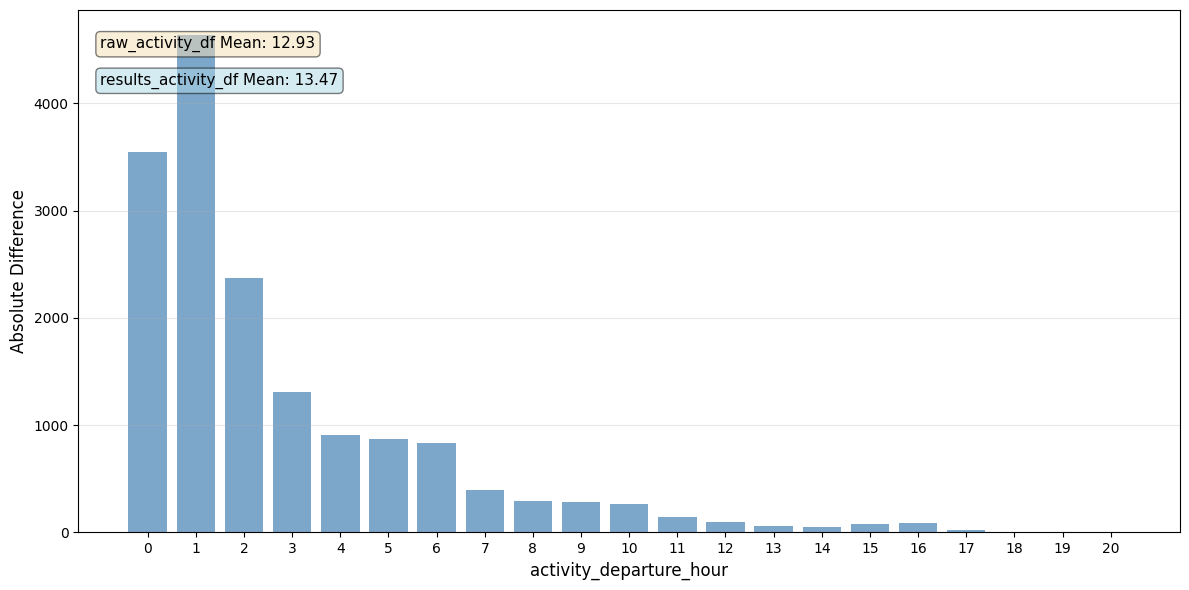

In [124]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 计算绝对差异
differences = abs(raw_activity_df['activity_出发时间1小时时间段'] - results_activity_df['activity_出发时间1小时时间段'])
print((differences==0).sum()/len(differences))
differences_stas = differences.value_counts()
# 计算两个数据源的均值
raw_mean = raw_activity_df['activity_出发时间1小时时间段'].mean()
results_mean = results_activity_df['activity_出发时间1小时时间段'].mean()

# 创建柱状图
plt.figure(figsize=(12, 6))
plt.bar(differences_stas.index, differences_stas.values, alpha=0.7, color='steelblue')
plt.xticks(differences_stas.index)
plt.xlabel('activity_departure_hour', fontsize=12)
plt.ylabel('Absolute Difference', fontsize=12)
# plt.title('家庭成员数量绝对差异分布', fontsize=14, fontweight='bold')

# 在空白处添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

0.22709970530451867


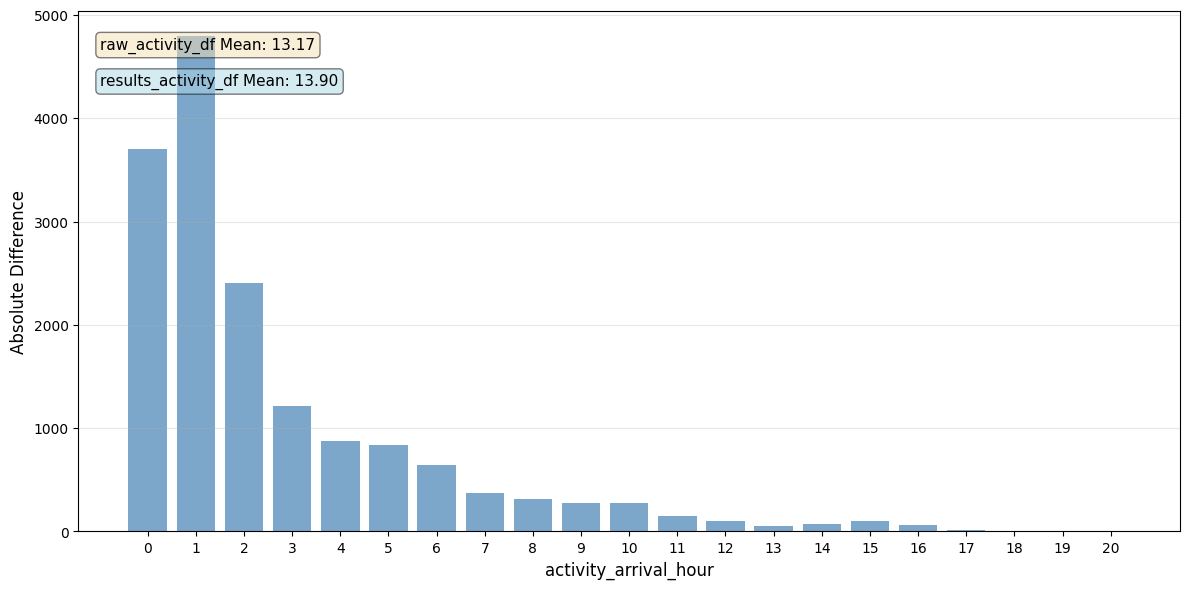

In [125]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 计算绝对差异
differences = abs(raw_activity_df['activity_到达时间1小时时间段'] - results_activity_df['activity_到达时间1小时时间段'])
print((differences==0).sum()/len(differences))
differences_stas = differences.value_counts()
# 计算两个数据源的均值
raw_mean = raw_activity_df['activity_到达时间1小时时间段'].mean()
results_mean = results_activity_df['activity_到达时间1小时时间段'].mean()

# 创建柱状图
plt.figure(figsize=(12, 6))
plt.bar(differences_stas.index, differences_stas.values, alpha=0.7, color='steelblue')
plt.xticks(differences_stas.index)
plt.xlabel('activity_arrival_hour', fontsize=12)
plt.ylabel('Absolute Difference', fontsize=12)
# plt.title('家庭成员数量绝对差异分布', fontsize=14, fontweight='bold')

# 在空白处添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

0.7526399803536346


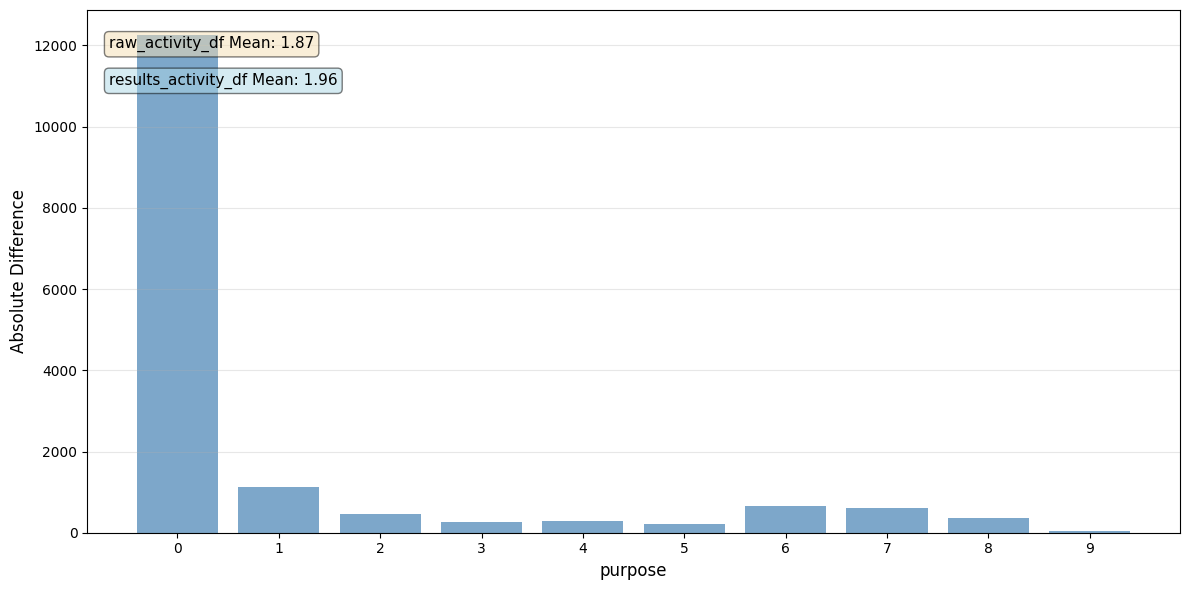

In [126]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 计算绝对差异
differences = abs(raw_activity_df['purpose'] - results_activity_df['purpose'])
print((differences==0).sum()/len(differences))
differences_stas = differences.value_counts()
# 计算两个数据源的均值
raw_mean = raw_activity_df['purpose'].mean()
results_mean = results_activity_df['purpose'].mean()

# 创建柱状图
plt.figure(figsize=(12, 6))
plt.bar(differences_stas.index, differences_stas.values, alpha=0.7, color='steelblue')
plt.xticks(differences_stas.index)
plt.xlabel('purpose', fontsize=12)
plt.ylabel('Absolute Difference', fontsize=12)
# plt.title('家庭成员数量绝对差异分布', fontsize=14, fontweight='bold')

# 在空白处添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [127]:
differences = (
    raw_activity_df['mode']
    .values[:, None]
    == results_activity_df[['pred_mode_1','pred_mode_2']].values
).any(axis=1)
print(differences.sum()/len(differences))

0.7038310412573674


0.5329690569744597


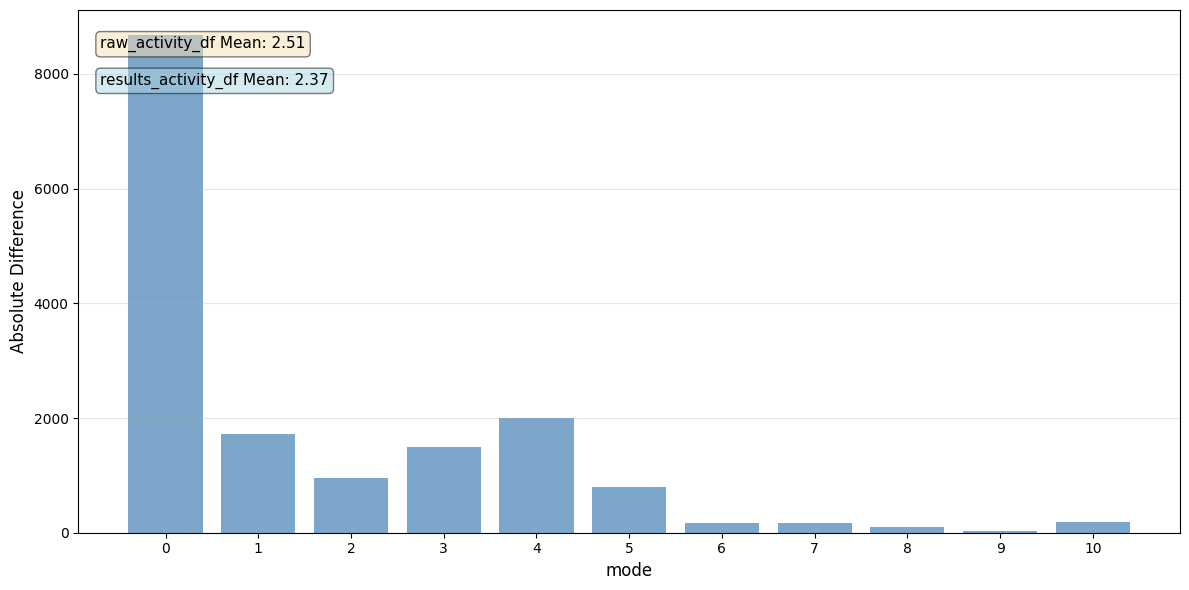

In [128]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 计算绝对差异
differences = abs(raw_activity_df['mode'] - results_activity_df['mode'])

print((differences==0).sum()/len(differences))
differences_stas = differences.value_counts()
# 计算两个数据源的均值
raw_mean = raw_activity_df['mode'].mean()
results_mean = results_activity_df['mode'].mean()

# 创建柱状图
plt.figure(figsize=(12, 6))
plt.bar(differences_stas.index, differences_stas.values, alpha=0.7, color='steelblue')
plt.xticks(differences_stas.index)
plt.xlabel('mode', fontsize=12)
plt.ylabel('Absolute Difference', fontsize=12)
# plt.title('家庭成员数量绝对差异分布', fontsize=14, fontweight='bold')

# 在空白处添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

0.8665275049115914


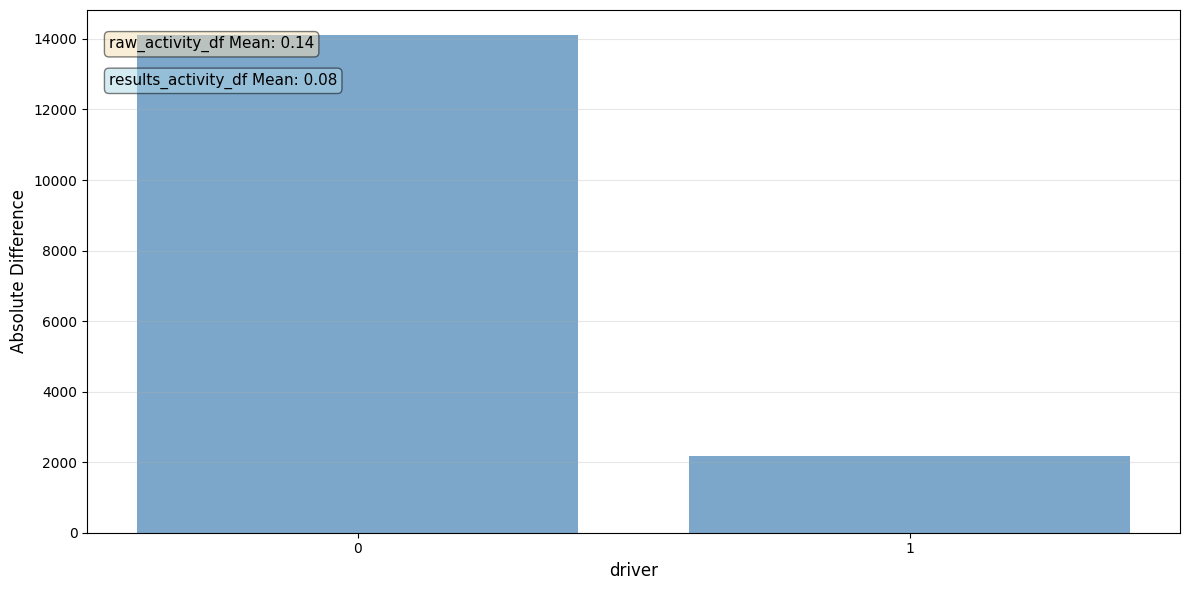

In [129]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 计算绝对差异
differences = abs(raw_activity_df['driver'] - results_activity_df['driver'])
print((differences==0).sum()/len(differences))
differences_stas = differences.value_counts()
# 计算两个数据源的均值
raw_mean = raw_activity_df['driver'].mean()
results_mean = results_activity_df['driver'].mean()

# 创建柱状图
plt.figure(figsize=(12, 6))
plt.bar(differences_stas.index, differences_stas.values, alpha=0.7, color='steelblue')
plt.xticks(differences_stas.index)
plt.xlabel('driver', fontsize=12)
plt.ylabel('Absolute Difference', fontsize=12)
# plt.title('家庭成员数量绝对差异分布', fontsize=14, fontweight='bold')

# 在空白处添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

0.4411836935166994


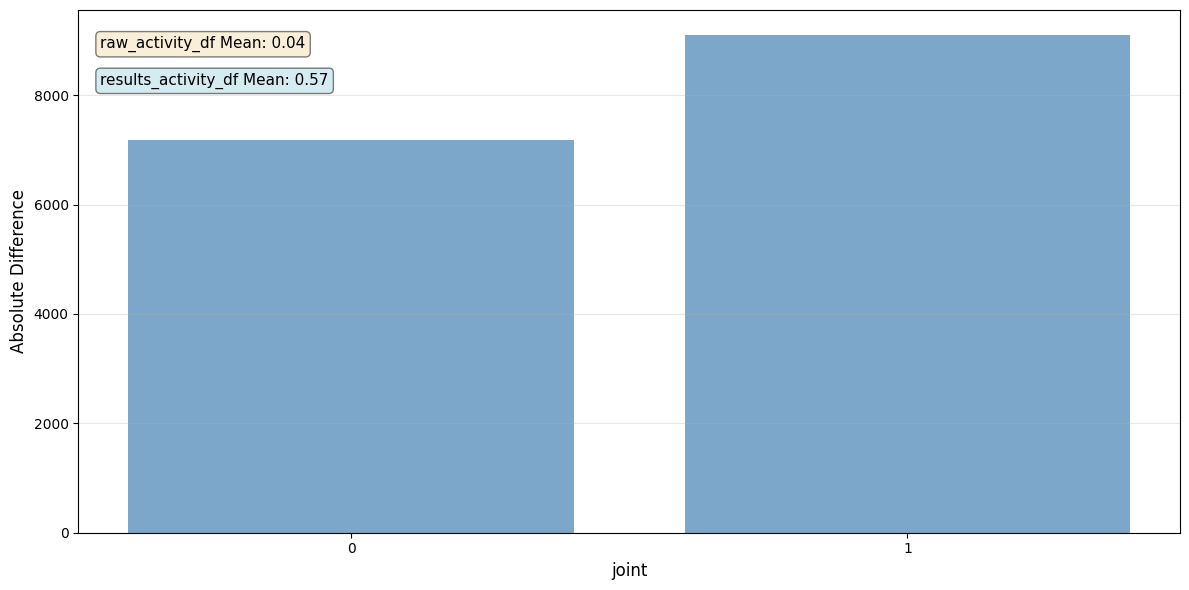

In [130]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 计算绝对差异
differences = abs(raw_activity_df['joint'] - results_activity_df['joint'])
print((differences==0).sum()/len(differences))
differences_stas = differences.value_counts()
# 计算两个数据源的均值
raw_mean = raw_activity_df['joint'].mean()
results_mean = results_activity_df['joint'].mean()

# 创建柱状图
plt.figure(figsize=(12, 6))
plt.bar(differences_stas.index, differences_stas.values, alpha=0.7, color='steelblue')
plt.xticks(differences_stas.index)
plt.xlabel('joint', fontsize=12)
plt.ylabel('Absolute Difference', fontsize=12)
# plt.title('家庭成员数量绝对差异分布', fontsize=14, fontweight='bold')

# 在空白处添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [131]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 计算绝对差异
differences = abs(raw_activity_df['目的地'] - results_activity_df['目的地'])
print((differences==0).sum()/len(differences))

differences = abs(raw_activity_df['出发地'] - results_activity_df['出发地'])
print((differences==0).sum()/len(differences))

0.7996684675834971
0.8284012770137524


## 精度比较2： 分布比较

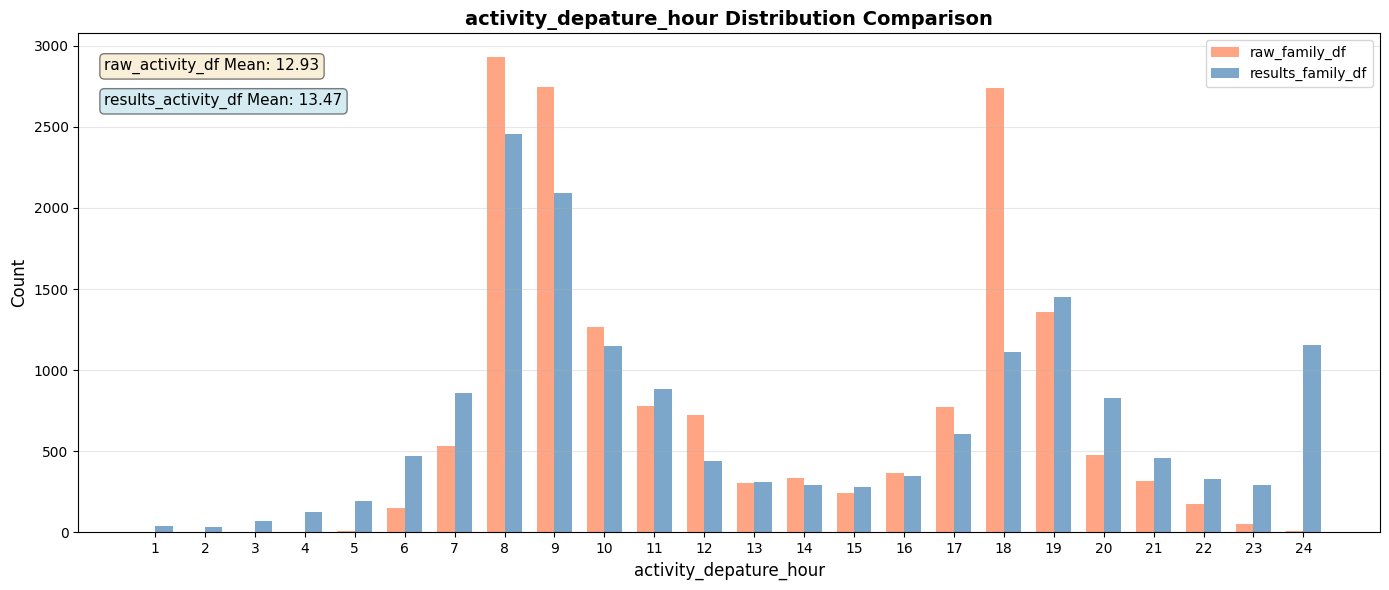

In [132]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取两个数据集的age分布
raw_age_counts = raw_activity_df['activity_出发时间1小时时间段'].value_counts().sort_index()
results_age_counts = results_activity_df['activity_出发时间1小时时间段'].value_counts().sort_index()

# 计算均值
raw_mean = raw_activity_df['activity_出发时间1小时时间段'].mean()
results_mean = results_activity_df['activity_出发时间1小时时间段'].mean()

# 创建一个合并的索引，确保包括两个数据集的所有年龄
all_ages = sorted(set(raw_age_counts.index) | set(results_age_counts.index))

# 准备绘图数据
raw_values = [raw_age_counts.get(age, 0) for age in all_ages]
results_values = [results_age_counts.get(age, 0) for age in all_ages]

# 创建柱状图
plt.figure(figsize=(14, 6))
x = np.arange(len(all_ages))
width = 0.35

plt.bar(x - width/2, raw_values, width, alpha=0.7, color='coral', label='raw_family_df')
plt.bar(x + width/2, results_values, width, alpha=0.7, color='steelblue', label='results_family_df')

plt.xticks(x, all_ages, rotation=90 if len(all_ages) > 30 else 0)
plt.xlabel('activity_depature_hour', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('activity_depature_hour Distribution Comparison', fontsize=14, fontweight='bold')
plt.legend()

# 添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

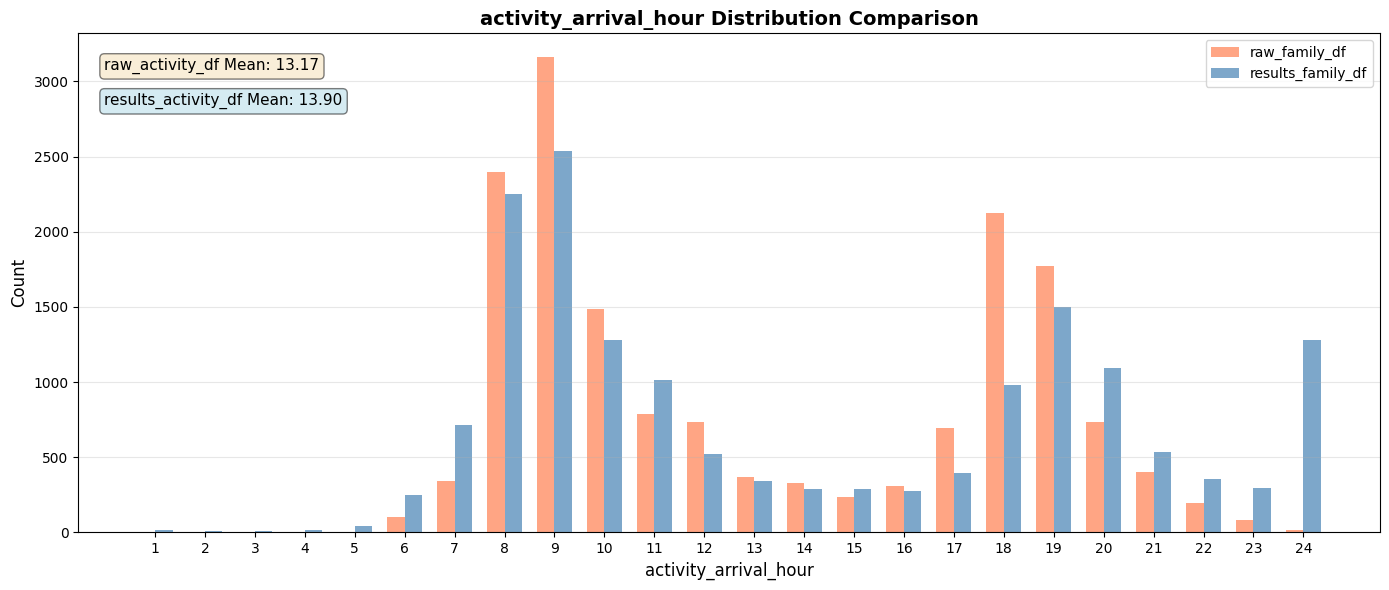

In [133]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取两个数据集的age分布
raw_age_counts = raw_activity_df['activity_到达时间1小时时间段'].value_counts().sort_index()
results_age_counts = results_activity_df['activity_到达时间1小时时间段'].value_counts().sort_index()

# 计算均值
raw_mean = raw_activity_df['activity_到达时间1小时时间段'].mean()
results_mean = results_activity_df['activity_到达时间1小时时间段'].mean()

# 创建一个合并的索引，确保包括两个数据集的所有年龄
all_ages = sorted(set(raw_age_counts.index) | set(results_age_counts.index))

# 准备绘图数据
raw_values = [raw_age_counts.get(age, 0) for age in all_ages]
results_values = [results_age_counts.get(age, 0) for age in all_ages]

# 创建柱状图
plt.figure(figsize=(14, 6))
x = np.arange(len(all_ages))
width = 0.35

plt.bar(x - width/2, raw_values, width, alpha=0.7, color='coral', label='raw_family_df')
plt.bar(x + width/2, results_values, width, alpha=0.7, color='steelblue', label='results_family_df')

plt.xticks(x, all_ages, rotation=90 if len(all_ages) > 30 else 0)
plt.xlabel('activity_arrival_hour', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('activity_arrival_hour Distribution Comparison', fontsize=14, fontweight='bold')
plt.legend()

# 添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

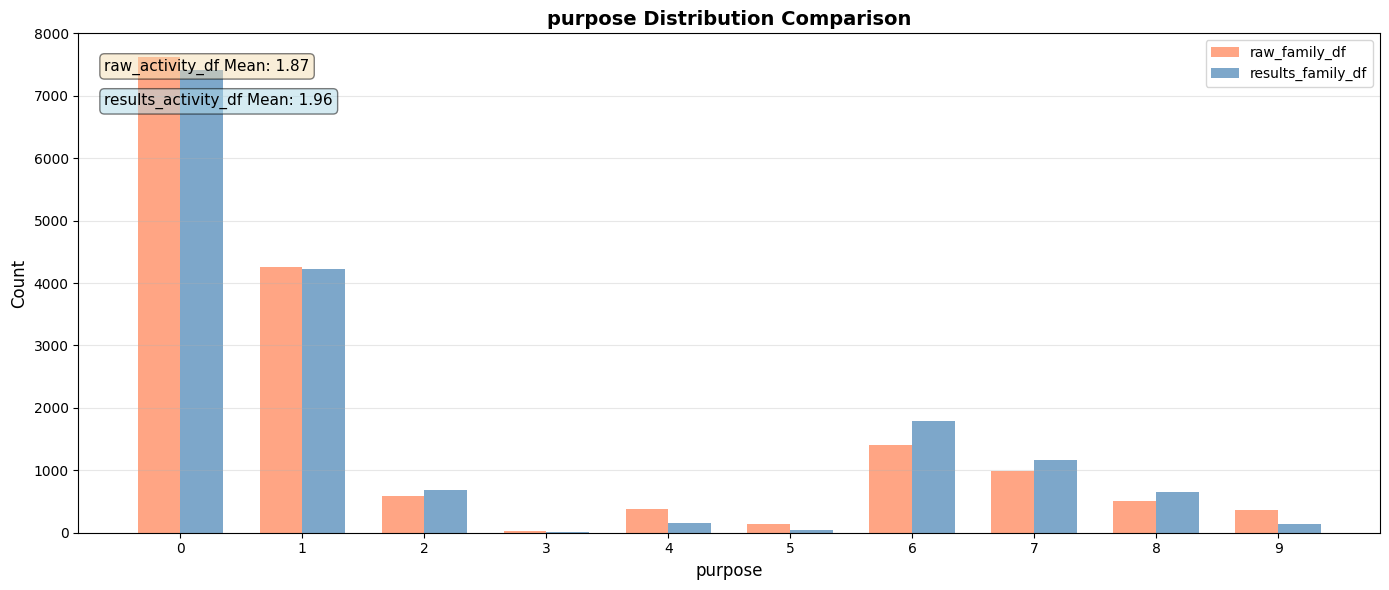

In [134]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取两个数据集的age分布
raw_age_counts = raw_activity_df['purpose'].value_counts().sort_index()
results_age_counts = results_activity_df['purpose'].value_counts().sort_index()

# 计算均值
raw_mean = raw_activity_df['purpose'].mean()
results_mean = results_activity_df['purpose'].mean()

# 创建一个合并的索引，确保包括两个数据集的所有年龄
all_ages = sorted(set(raw_age_counts.index) | set(results_age_counts.index))

# 准备绘图数据
raw_values = [raw_age_counts.get(age, 0) for age in all_ages]
results_values = [results_age_counts.get(age, 0) for age in all_ages]

# 创建柱状图
plt.figure(figsize=(14, 6))
x = np.arange(len(all_ages))
width = 0.35

plt.bar(x - width/2, raw_values, width, alpha=0.7, color='coral', label='raw_family_df')
plt.bar(x + width/2, results_values, width, alpha=0.7, color='steelblue', label='results_family_df')

plt.xticks(x, all_ages, rotation=90 if len(all_ages) > 30 else 0)
plt.xlabel('purpose', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('purpose Distribution Comparison', fontsize=14, fontweight='bold')
plt.legend()

# 添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

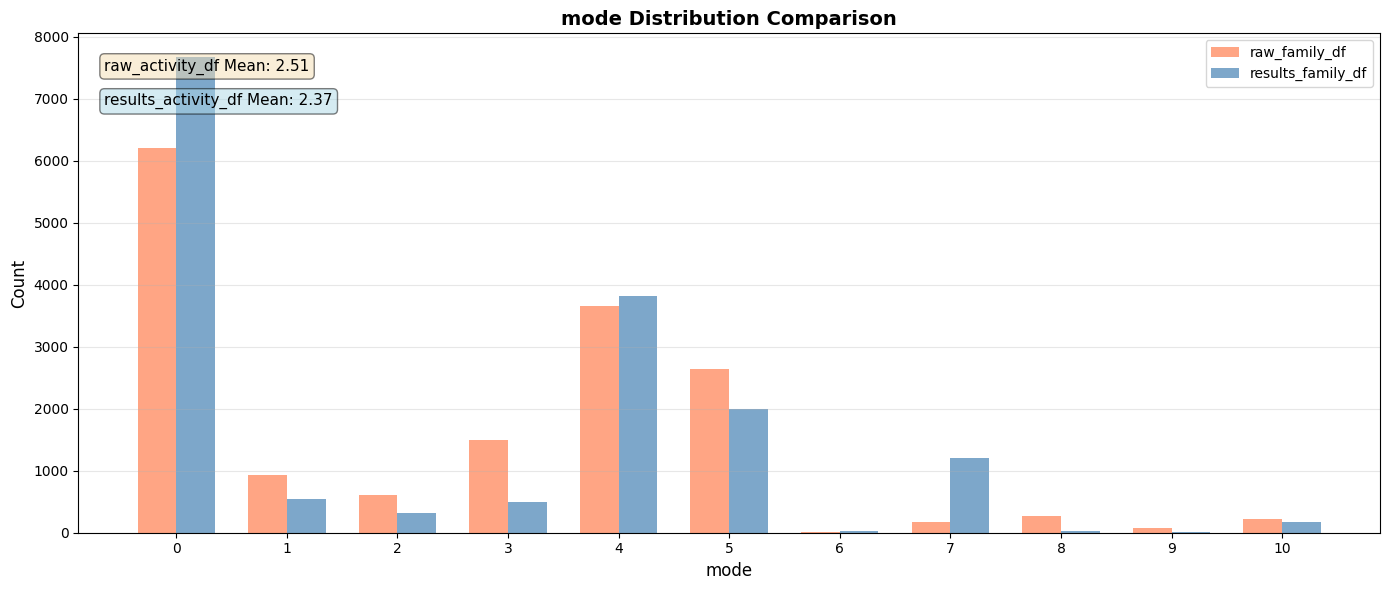

In [135]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取两个数据集的age分布
raw_age_counts = raw_activity_df['mode'].value_counts().sort_index()
results_age_counts = results_activity_df['mode'].value_counts().sort_index()

# 计算均值
raw_mean = raw_activity_df['mode'].mean()
results_mean = results_activity_df['mode'].mean()

# 创建一个合并的索引，确保包括两个数据集的所有年龄
all_ages = sorted(set(raw_age_counts.index) | set(results_age_counts.index))

# 准备绘图数据
raw_values = [raw_age_counts.get(age, 0) for age in all_ages]
results_values = [results_age_counts.get(age, 0) for age in all_ages]

# 创建柱状图
plt.figure(figsize=(14, 6))
x = np.arange(len(all_ages))
width = 0.35

plt.bar(x - width/2, raw_values, width, alpha=0.7, color='coral', label='raw_family_df')
plt.bar(x + width/2, results_values, width, alpha=0.7, color='steelblue', label='results_family_df')

plt.xticks(x, all_ages, rotation=90 if len(all_ages) > 30 else 0)
plt.xlabel('mode', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('mode Distribution Comparison', fontsize=14, fontweight='bold')
plt.legend()

# 添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

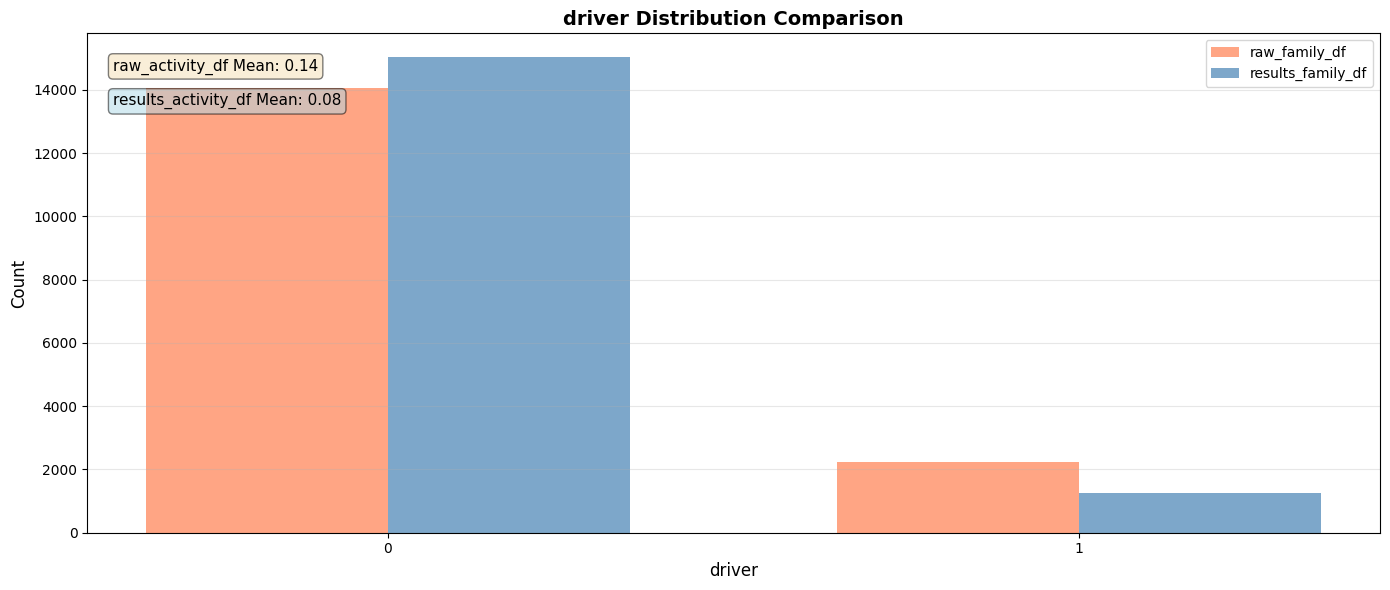

In [136]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取两个数据集的age分布
raw_age_counts = raw_activity_df['driver'].value_counts().sort_index()
results_age_counts = results_activity_df['driver'].value_counts().sort_index()

# 计算均值
raw_mean = raw_activity_df['driver'].mean()
results_mean = results_activity_df['driver'].mean()

# 创建一个合并的索引，确保包括两个数据集的所有年龄
all_ages = sorted(set(raw_age_counts.index) | set(results_age_counts.index))

# 准备绘图数据
raw_values = [raw_age_counts.get(age, 0) for age in all_ages]
results_values = [results_age_counts.get(age, 0) for age in all_ages]

# 创建柱状图
plt.figure(figsize=(14, 6))
x = np.arange(len(all_ages))
width = 0.35

plt.bar(x - width/2, raw_values, width, alpha=0.7, color='coral', label='raw_family_df')
plt.bar(x + width/2, results_values, width, alpha=0.7, color='steelblue', label='results_family_df')

plt.xticks(x, all_ages, rotation=90 if len(all_ages) > 30 else 0)
plt.xlabel('driver', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('driver Distribution Comparison', fontsize=14, fontweight='bold')
plt.legend()

# 添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

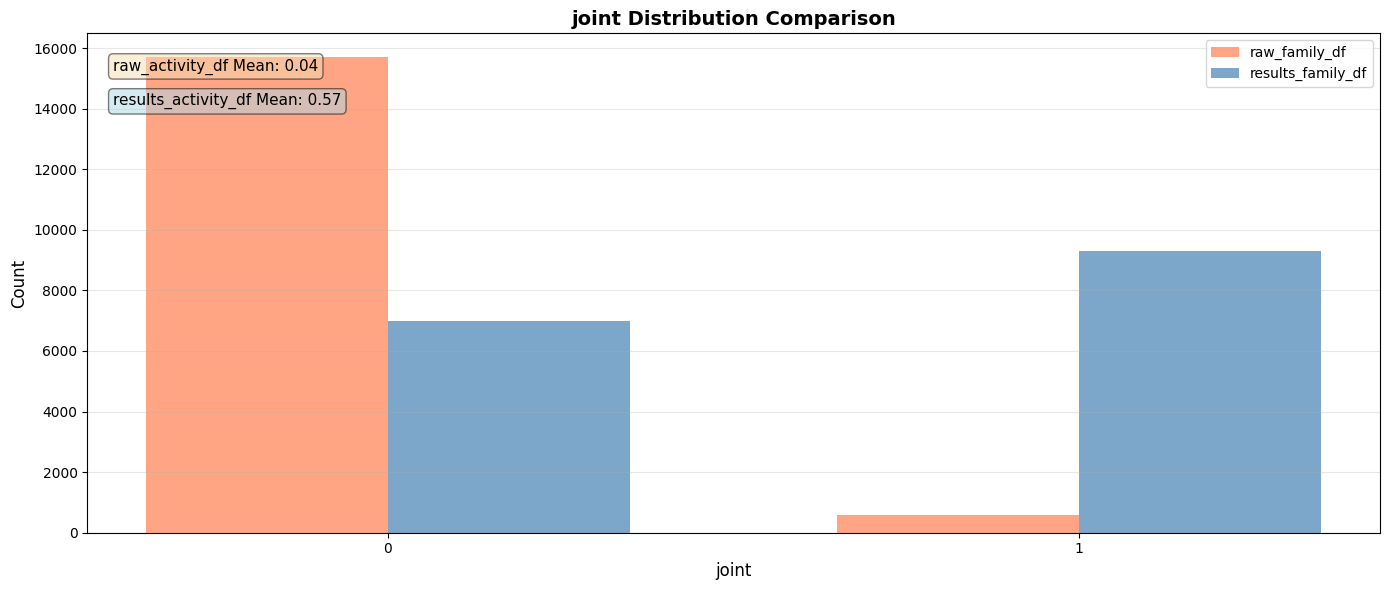

In [137]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取两个数据集的age分布
raw_age_counts = raw_activity_df['joint'].value_counts().sort_index()
results_age_counts = results_activity_df['joint'].value_counts().sort_index()

# 计算均值
raw_mean = raw_activity_df['joint'].mean()
results_mean = results_activity_df['joint'].mean()

# 创建一个合并的索引，确保包括两个数据集的所有年龄
all_ages = sorted(set(raw_age_counts.index) | set(results_age_counts.index))

# 准备绘图数据
raw_values = [raw_age_counts.get(age, 0) for age in all_ages]
results_values = [results_age_counts.get(age, 0) for age in all_ages]

# 创建柱状图
plt.figure(figsize=(14, 6))
x = np.arange(len(all_ages))
width = 0.35

plt.bar(x - width/2, raw_values, width, alpha=0.7, color='coral', label='raw_family_df')
plt.bar(x + width/2, results_values, width, alpha=0.7, color='steelblue', label='results_family_df')

plt.xticks(x, all_ages, rotation=90 if len(all_ages) > 30 else 0)
plt.xlabel('joint', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('joint Distribution Comparison', fontsize=14, fontweight='bold')
plt.legend()

# 添加均值标注
plt.text(0.02, 0.95, f'raw_activity_df Mean: {raw_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'results_activity_df Mean: {results_mean:.2f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [138]:
raw_activity_df.drop(columns=['distance'], inplace=True)
results_activity_df.drop(columns=['mode_real', 'distance'], inplace=True)

In [139]:
import itertools
import numpy as np
import pandas as pd
def calc_srmse(raw_df, synth_df, max_value_list):
    srmse_results = {}

    # 遍历所有可能的属性组合（1维、2维、...）
    for r in range(1, len(max_value_list) + 1):
        number_of_combinations = 0
        srmse_sum = 0.0
        for cols in itertools.combinations(raw_df.columns, r):
            # 计算联合分布频率
            real_counts = raw_df.groupby(list(cols)).size().reset_index(name='count')
            synth_counts = synth_df.groupby(list(cols)).size().reset_index(name='count')

            # 合并并补全缺失组合
            merged = pd.merge(real_counts, synth_counts, on=list(cols), how='outer', suffixes=('_real', '_synth')).fillna(0)

            # 转换为频率分布
            # merged['π_real'] = merged['count_real'] / merged['count_real'].sum()
            # merged['π_synth'] = merged['count_synth'] / merged['count_synth'].sum()

            merged['π_real'] = merged['count_real']
            merged['π_synth'] = merged['count_synth']
            # 计算 SRMSE
            N_cnt = len(merged)
            numerator = np.sqrt(((merged['π_synth'] - merged['π_real']) ** 2).sum() / N_cnt)
            denominator = (merged['π_real'].sum()) / N_cnt
            srmse = numerator / denominator if denominator != 0 else np.nan
            # srmse = numerator

            srmse_results[cols] = srmse
            srmse_sum += srmse
            number_of_combinations += 1
        avg_srmse = srmse_sum / number_of_combinations if number_of_combinations > 0 else np.nan
        print(f'Average SRMSE for {r}-dimensional combinations: {avg_srmse}')
        srmse_results[f'avg_srmse_{r}_dims'] = avg_srmse

    return srmse_results



## 指标计算

In [140]:
# 示例调用
srmse_results = calc_srmse(raw_activity_df[['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地']], results_activity_df[['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地']], ['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地'])

Average SRMSE for 1-dimensional combinations: 0.44747095781409685
Average SRMSE for 2-dimensional combinations: 1.3525308873181314
Average SRMSE for 3-dimensional combinations: 1.6757941895683286
Average SRMSE for 4-dimensional combinations: 1.8430066828955682


In [141]:
# 示例调用
srmse_results = calc_srmse(raw_activity_df[['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地','purpose']], results_activity_df[['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地','purpose']], ['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地','purpose'])

Average SRMSE for 1-dimensional combinations: 0.38120968364865526
Average SRMSE for 2-dimensional combinations: 1.289197282378034
Average SRMSE for 3-dimensional combinations: 1.7137076333480237
Average SRMSE for 4-dimensional combinations: 1.825198453868366
Average SRMSE for 5-dimensional combinations: 1.9133203061800843


In [142]:
# 示例调用
srmse_results = calc_srmse(raw_activity_df[['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地','mode']], results_activity_df[['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地','mode']], ['activity_出发时间1小时时间段', 'activity_到达时间1小时时间段','出发地', '目的地','mode'])

Average SRMSE for 1-dimensional combinations: 0.4488364256991371
Average SRMSE for 2-dimensional combinations: 1.2866943886011974
Average SRMSE for 3-dimensional combinations: 1.7446352868309194
Average SRMSE for 4-dimensional combinations: 1.8734495764700179
Average SRMSE for 5-dimensional combinations: 1.9525571835772508


In [143]:
# 示例调用
srmse_results = calc_srmse(raw_activity_df, results_activity_df, results_activity_df.columns)

Average SRMSE for 1-dimensional combinations: 0.443680372834143
Average SRMSE for 2-dimensional combinations: 1.2054330764087438
Average SRMSE for 3-dimensional combinations: 1.8913865796899485
Average SRMSE for 4-dimensional combinations: 2.207921685901645
Average SRMSE for 5-dimensional combinations: 2.234008657490113
Average SRMSE for 6-dimensional combinations: 2.147845472194334
Average SRMSE for 7-dimensional combinations: 2.077741163882482
Average SRMSE for 8-dimensional combinations: 2.087077039423836
Average SRMSE for 9-dimensional combinations: nan
Average SRMSE for 10-dimensional combinations: nan
